# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Akshay Prakash (2503690F)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Preprocessing and splitting (scikit-learn only, per project specification)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_validate, StratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

## Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

# 1. Business Understanding

**Objective:** predict the presence of heart disease from 11 routinely-collected clinical measurements (age, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG, max heart rate achieved, exercise-induced angina, ST depression/slope), enabling a clinician to escalate a patient toward cardiology review *before* the condition reaches a critical stage.

**Problem framing:** binary classification. Target `HeartDisease` — `1` indicates disease present, `0` indicates no disease.

The two ways this model can be wrong carry very different consequences:

| Outcome | **What it looks like in practice** | **Who bears the consequence** |
| --- | --- | --- |
| **Missed case** (false negative) | a patient who actually has heart disease is cleared and sent home with no referral | the patient, whose disease progresses silently toward a potential heart attack, stroke, or sudden cardiac death — and, further downstream, the health system, which absorbs the far higher cost of emergency cardiac care versus the cost of early intervention it skipped |
| **False alarm** (false positive) | a healthy patient is flagged and sent for additional cardiac workup (e.g. stress test, angiogram) | the patient, who incurs added expense, anxiety, and the small but real procedural risk of an invasive test they didn't need |

Because these two outcomes are priced so differently, the class split is beside the point — even a perfectly balanced dataset would still make accuracy the wrong number to optimize for, since it treats both mistakes as equally bad when they clearly aren't.

This model is intended to sit in a primary-care setting as a triage aid — a second opinion a GP consults during a routine visit — rather than as a cardiologist's final diagnostic tool or a consumer-facing app used without clinical oversight. Under that framing, a missed case is the more expensive mistake in three distinct ways: clinically, because untreated disease progresses toward an acute event — heart attack, stroke, or sudden cardiac death — with worse outcomes and fewer treatment options the longer it goes undetected; financially, because the eventual cost of emergency treatment, hospitalization, or long-term cardiac damage management dwarfs what an earlier referral and preventive treatment would have cost, a pattern well documented in health-economics literature on delayed cardiac diagnosis; and in the worst case, irreversibly, since a missed diagnosis can end in permanent disability or death rather than a cost that's merely expensive to fix. A false alarm is not free, either: it costs the patient money, stress, and exposure to procedural risk from a test they didn't need, and it consumes limited specialist capacity that a true case could have used instead — but it is recoverable in a way a missed fatal event is not. Given this, the model should be tuned to favor recall over precision, but deliberately, with a stated threshold or cost ratio in section 5 — not by default, and not so far in that precision collapses and false alarms start eating away at the very capacity we're trying to protect.

**Working assumptions**

1. The 11 input features are obtainable through a standard clinical workup — history, resting ECG, and a fasting blood panel (cholesterol, fasting blood sugar). Note this is *not* all available in a single instant office visit: cholesterol and fasting blood sugar require prior fasting and lab turnaround, so in practice the full feature set is assembled over one or two visits rather than in real time during triage.
2. The model's output supports a referral decision; it does not stand in for clinical judgment or constitute a diagnosis.
3. The training population is assumed to reasonably reflect the deployment population. This is worth treating skeptically rather than as a formality — this dataset is a merge of five separate cohorts collected across different countries and time periods, so distributional mismatch is a live risk to revisit in the EDA/limitations discussion.
4. The physiological relationships between these clinical markers and heart disease are not expected to drift quickly over time — so a recall/precision tradeoff chosen now should stay reasonably valid without frequent retraining.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("dataset.csv")

## Keep an untouched copy so that cleaning in section 3 can be compared against the raw data
df_raw = df.copy()

print("Rows:", df.shape[0], " Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

df.head()

Rows: 918  Columns: 12
Duplicate rows: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


The dataset loads with 918 patient records and 12 columns: 11 predictors and the `HeartDisease` target. This clears the 200-sample minimum, but it is small enough that the train-test split in section 3.2 must be stratified, otherwise the test set may not preserve the class ratio and the reported metrics will be unstable.

Source: Fedesoriano, *Heart Failure Prediction Dataset* (Kaggle). This file is a merge of five separate cardiology cohorts — Cleveland, Hungarian, Switzerland, Long Beach VA and Stalog — with 272 duplicate records already removed by the compiler, which is why `duplicated()` returns zero here. That merge is not a background detail: it is the origin of the data quality problem uncovered in 2.2 and the main threat to how this model generalises.

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

## Group columns by how they will need to be handled later.
## FastingBS is stored as a number but is really a 0/1 flag, so it is grouped with
## the categorical columns and will not be scaled like a continuous measurement.
target = "HeartDisease"
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
category_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS"]

## Print the levels of each categorical column to catch typos or unexpected values
print("\nCategorical levels:")
for col in category_cols:
    print(col, "->", sorted(df[col].unique().tolist(), key=str))

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB

Categorical levels:
Sex -> ['F', 'M']
ChestPainType -> ['ASY', 'ATA', 'NAP', 'TA']
RestingECG -> ['LVH', 'Normal', 'ST']
ExerciseAngina -> ['N', 'Y']
ST_Slope -> ['Down', 'Flat', 'Up']
FastingBS -> [0, 1]


In [4]:
## Check for missing data

## Count explicit missing values
print("Explicit missing values per column:")
print(df.isna().sum())

## A value of 0 is biologically impossible for these measurements, so a 0 recorded
## here is really a missing value in disguise. isna() will not find these.
print("\nZeros in columns where 0 is impossible:")
for col in ["RestingBP", "Cholesterol", "MaxHR"]:
    n = (df[col] == 0).sum()
    print(col, ":", n, "rows (", round(n / len(df) * 100, 1), "% )")

## Check whether the disguised missing values are spread evenly across the target.
## If they are not, "this test was never run" is itself a clue about the diagnosis,
## which is a leakage risk rather than a clinical signal.
print("\nDisease rate by whether cholesterol was recorded:")
print(df.groupby(df["Cholesterol"] == 0)[target].mean().round(3))
print("\nRow counts:")
print(df.groupby(df["Cholesterol"] == 0)[target].size())

Explicit missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zeros in columns where 0 is impossible:
RestingBP : 1 rows ( 0.1 % )
Cholesterol : 172 rows ( 18.7 % )
MaxHR : 0 rows ( 0.0 % )

Disease rate by whether cholesterol was recorded:
Cholesterol
False    0.477
True     0.884
Name: HeartDisease, dtype: float64

Row counts:
Cholesterol
False    746
True     172
Name: HeartDisease, dtype: int64


In [5]:
## Describe data distribution

## Spread and central tendency of the continuous columns
print("Continuous features:")
display(df[numeric_cols].describe().round(2))

## Skew tells us whether a distribution is lopsided enough to need a transform
print("Skewness (values beyond +/-1 are heavily one-sided):")
print(df[numeric_cols].skew().round(2))

## Proportions rather than raw counts, so rare categories are easy to spot
print("\nCategory proportions (%):")
for col in category_cols:
    print("\n" + col)
    print((df[col].value_counts(normalize=True) * 100).round(1))

Continuous features:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,136.81,0.89
std,9.43,18.51,109.38,25.46,1.07
min,28.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,120.00,0.00
50%,54.00,130.00,223.00,138.00,0.60
75%,60.00,140.00,267.00,156.00,1.50
max,77.00,200.00,603.00,202.00,6.20


Skewness (values beyond +/-1 are heavily one-sided):
Age           -0.20
RestingBP      0.18
Cholesterol   -0.61
MaxHR         -0.14
Oldpeak        1.02
dtype: float64

Category proportions (%):

Sex
Sex
M    79.0
F    21.0
Name: proportion, dtype: float64

ChestPainType
ChestPainType
ASY    54.0
NAP    22.1
ATA    18.8
TA      5.0
Name: proportion, dtype: float64

RestingECG
RestingECG
Normal    60.1
LVH       20.5
ST        19.4
Name: proportion, dtype: float64

ExerciseAngina
ExerciseAngina
N    59.6
Y    40.4
Name: proportion, dtype: float64

ST_Slope
ST_Slope
Flat    50.1
Up      43.0
Down     6.9
Name: proportion, dtype: float64

FastingBS
FastingBS
0    76.7
1    23.3
Name: proportion, dtype: float64


### 2.2.1 What the summary statistics reveal

**`isna()` reports zero missing values, and that is misleading.** Two columns contain values that cannot occur in a living patient:

| Column | Impossible value | Count | Share | What it actually means |
| --- | --- | --- | --- | --- |
| `Cholesterol` | 0 mg/dl | 172 | 18.7% | no lipid panel was ever drawn |
| `RestingBP` | 0 mm Hg | 1 | 0.1% | a data-entry error |

No living patient has a serum cholesterol of zero. These are missing values wearing a numeric disguise. Left untouched they pull the reported mean cholesterol down to 198.8 mg/dl, roughly 46 mg/dl below the true mean of the measured patients, and teach the model that "extremely low cholesterol" is a real clinical state when it is really an absent lab result. The same artefact is what makes `Cholesterol` skew negative (−0.61) despite serum cholesterol being a naturally right-tailed measurement.

**The missingness is not random, and this is the most important finding in the whole EDA.** Grouping the target by whether cholesterol was recorded is stark: patients with a recorded value are disease-positive 47.7% of the time, while patients whose cholesterol reads 0 are disease-positive **88.4%** of the time. The cause is structural, not clinical — the merged cohorts did not all collect lipid panels, and the sub-cohort that skipped them also happens to have far higher disease prevalence. In other words, *whether the test was run* predicts the outcome better than *the test result*.

**Implication for modelling.** This is a trap in both directions. Mean-imputing the zeros injects that 88.4% disease signal into a feature meant to carry cholesterol information, inflating test scores in a way that will collapse on a single hospital's patients. Dropping the 172 rows discards nearly a fifth of the data and, because those rows skew heavily disease-positive, shifts the class balance. Section 3.1 therefore imputes the value **and** keeps a `Cholesterol_missing` flag, so the model uses "no lipid panel on file" openly instead of laundering it through the cholesterol column. This is the concrete form of assumption 3: a model leaning on this artefact has learned which hospital a record came from, not which patient is sick.

**Cohort skew that limits what the headline metric means.** 79.0% of the sample is male, so any single accuracy or recall figure in section 5 is mainly a statement about male patients — female performance must be reported separately, not assumed equal. `ChestPainType` is dominated by asymptomatic (`ASY`) cases at 54.0%, and `ST_Slope = Down` accounts for only 6.9% of records (≈63 patients), a level rare enough to produce a sparse, high-variance column after one-hot encoding.

**Scale.** `Cholesterol` (0–603) and `MaxHR` (60–202) sit on very different ranges from `Oldpeak` (−2.6 to 6.2). Distance- and gradient-based models need scaling; tree ensembles do not. Section 3 applies scaling inside a `Pipeline` so the scaler never sees test-set statistics.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

In [6]:
## One consistent style for every figure, so colour always means the same thing:
## green = no disease, red = heart disease.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PALETTE = {0: "#4C9F70", 1: "#C0392B"}
LABELS = {0: "No disease", 1: "Heart disease"}

### 2.3.1.1 Understanding distribution of target

No disease   : 410 patients ( 44.7 % )
Heart disease: 508 patients ( 55.3 % )
Majority-class baseline accuracy: 55.3 %


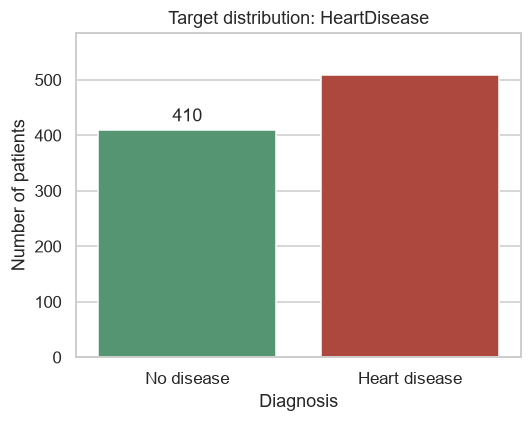

In [7]:
## Understanding distribution of target

## Count and percentage of each class
counts = df[target].value_counts().sort_index()
percent = (df[target].value_counts(normalize=True).sort_index() * 100).round(1)

print("No disease   :", counts[0], "patients (", percent[0], "% )")
print("Heart disease:", counts[1], "patients (", percent[1], "% )")
print("Majority-class baseline accuracy:", percent.max(), "%")

## Bar chart of the class balance
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=target, hue=target, palette=PALETTE, legend=False, ax=ax)
ax.set_title("Target distribution: HeartDisease")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of patients")
ax.set_xticks([0, 1])
ax.set_xticklabels([LABELS[0], LABELS[1]])
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Interpretation.** The split is 508 disease-positive (55.3%) against 410 negative (44.7%), a ratio of about 1.24 : 1. That is mild enough that resampling, class weighting or SMOTE would be solving a problem that does not exist, and all three would distort the predicted probabilities that section 5's threshold selection depends on. No rebalancing is applied.

Two consequences follow. First, **the baseline every model must beat is 55.3% accuracy** — the score obtained by predicting "heart disease" for everyone. A model reporting 78% accuracy is beating a coin flip, not beating that trivial strategy, and only the gap between the two is a real claim. This baseline is reported alongside every model in sections 4 and 5.

Second, near-balance does not rescue accuracy as the headline metric. Balance makes accuracy *interpretable*; it does not make it *appropriate*. Accuracy scores a missed heart disease case and a false referral identically, when the first can end in a fatal cardiac event and the second ends in an unnecessary but survivable test. The metric choice in section 5 follows from that asymmetry, not from this ratio.

One caveat that limits deployment: 55.3% prevalence describes a **referred cardiology cohort**, not the general population, where prevalence is far lower. A model calibrated on this base rate will over-predict disease on unselected primary-care walk-ins. The threshold chosen in section 5 is valid for the referred population this dataset represents, and would need recalibration before wider use.

### 2.3.1.2 Understanding distribution of features

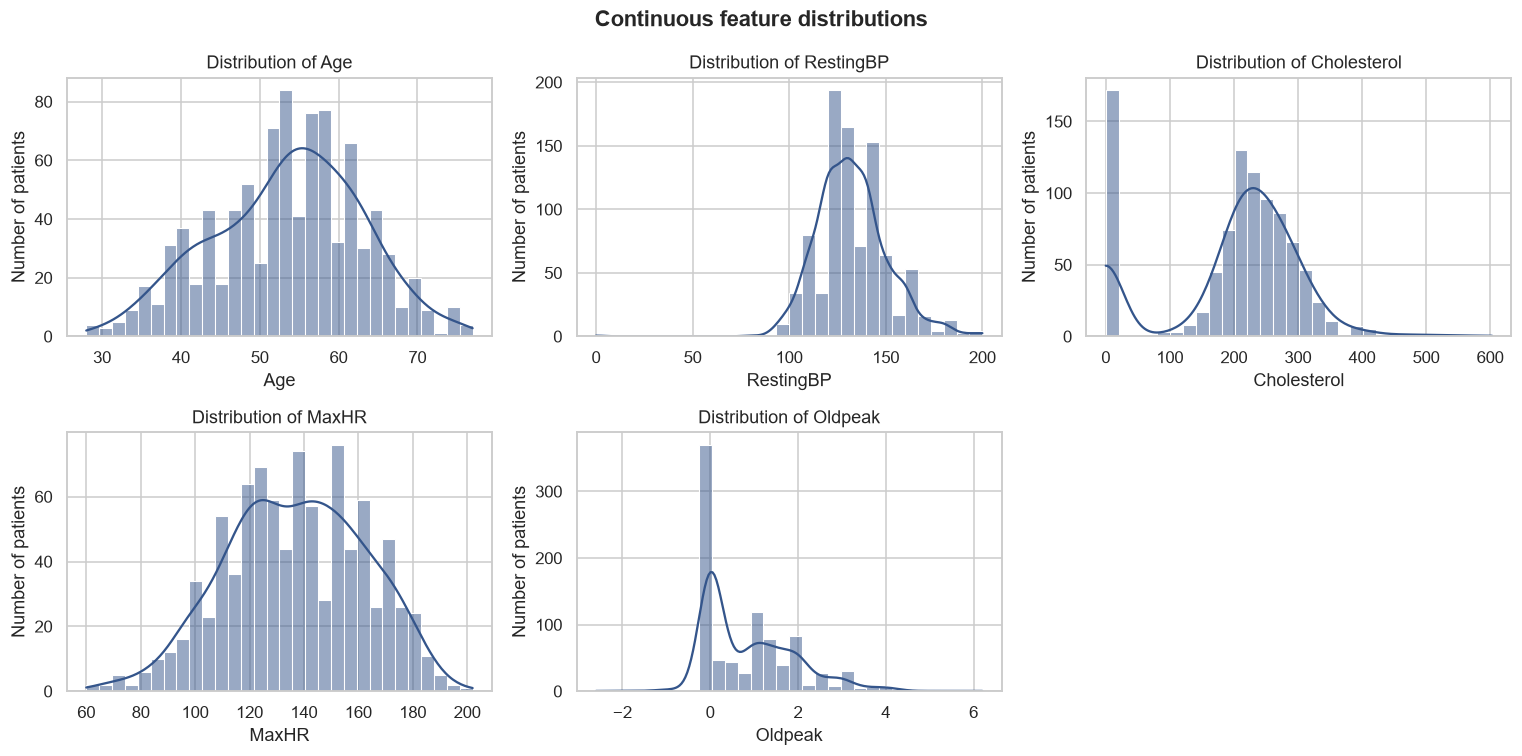

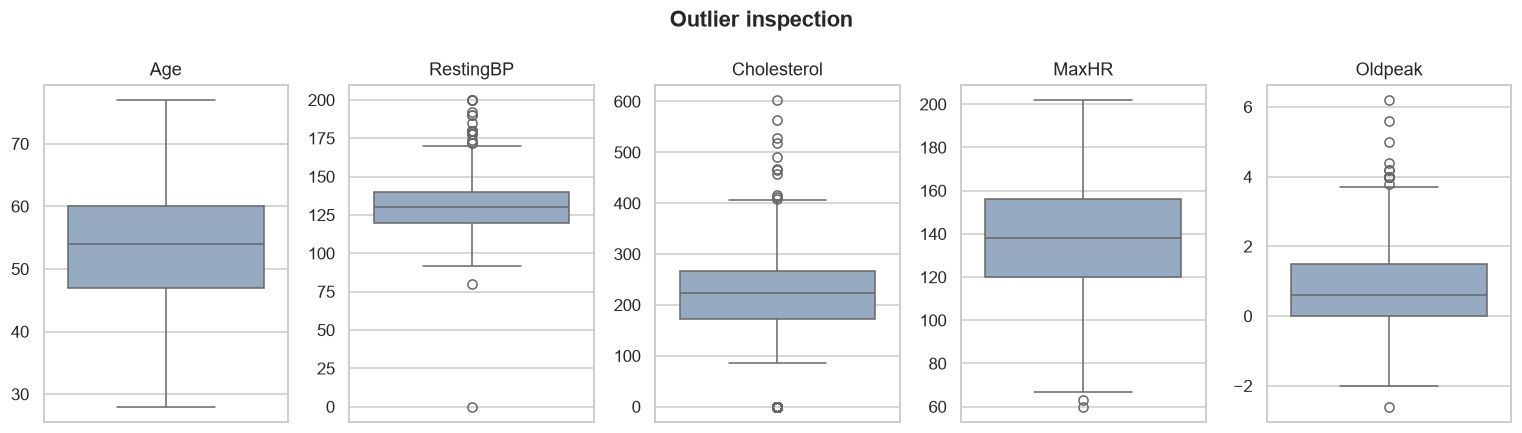

Outliers using the 1.5 x IQR rule:
Age : 0 rows ( 0.0 % )
RestingBP : 28 rows ( 3.1 % )
Cholesterol : 183 rows ( 19.9 % )
MaxHR : 2 rows ( 0.2 % )
Oldpeak : 16 rows ( 1.7 % )


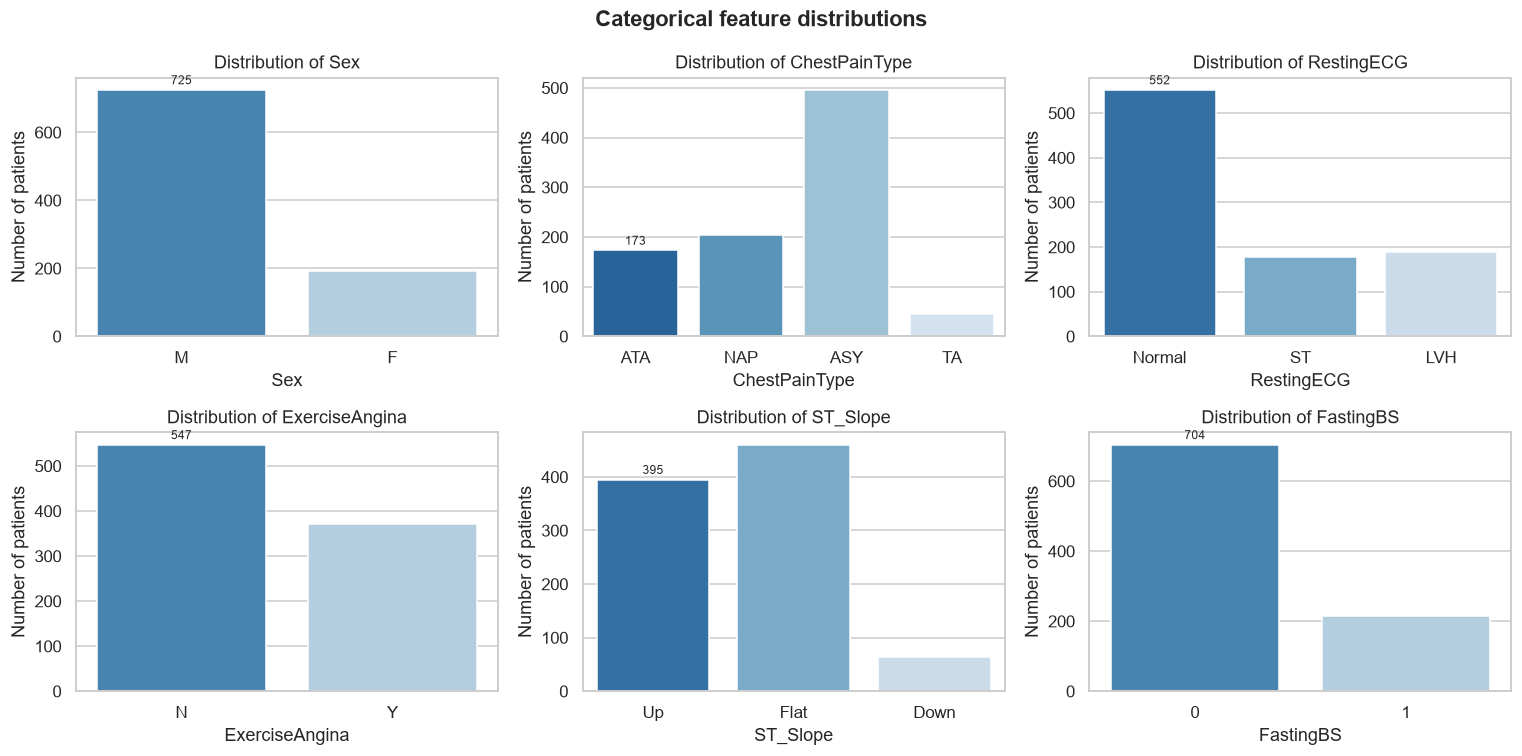

In [8]:
## Understanding distribution of features

## Histograms show the shape of each continuous feature and expose impossible values
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, color="#34558B", ax=axes[i])
    axes[i].set_title("Distribution of " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of patients")
axes[-1].axis("off")
fig.suptitle("Continuous feature distributions", fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots make outliers easy to see
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, color="#8FA9C9", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
fig.suptitle("Outlier inspection", fontweight="bold")
plt.tight_layout()
plt.show()

## Count the outliers so the discussion is based on numbers, not just the picture
print("Outliers using the 1.5 x IQR rule:")
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, ":", n, "rows (", round(n / len(df) * 100, 1), "% )")

## Bar charts for the categorical features, with counts labelled so rare levels stand out
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(category_cols):
    sns.countplot(data=df, x=col, hue=col, palette="Blues_r", legend=False, ax=axes[i])
    axes[i].set_title("Distribution of " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of patients")
    axes[i].bar_label(axes[i].containers[0], fontsize=8, padding=2)
fig.suptitle("Categorical feature distributions", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.**

`Age` is close to symmetric (skew −0.20), centred on a mean of 53.5 and spanning 28 to 77 — a plausible referral range with no absurd values and zero IQR outliers, so no transform is needed.

`Cholesterol` confirms the 2.2 finding visually: instead of one smooth distribution there is a **tall spike at exactly 0**, separated from an otherwise roughly normal body of measured values centred near 240. That spike is the 172 unmeasured patients, and it is what drives the counterintuitive negative skew (−0.61). There is also a genuine extreme at 603 mg/dl, which is clinically rare but real and should be kept rather than trimmed.

`RestingBP` has a single record at 0 mm Hg. Unlike the cholesterol zeros this is not a systematic collection gap but one data-entry error, so section 3.1 drops the row rather than imputing it.

`Oldpeak` is the only meaningfully skewed feature (skew 1.02), with a large stack at 0 (patients with no exercise-induced ST depression) and a few negative values. No log transform is applied: the zero is meaningful — it means no ST depression was observed — and a transform would destroy that interpretable anchor.

`MaxHR` is broadly symmetric across 60–202 bpm, consistent with an exercise stress test population.

Among the categoricals, the striking result is that **`ChestPainType` is dominated by `ASY` (asymptomatic) at 54.0%**. The largest single group in a cardiology cohort presented *without* classic chest pain. That undercuts any product built on symptom-led screening: a tool waiting for a patient to report chest pain would miss the majority of this population — which is precisely the argument for a model reading the full panel of markers instead.

`ST_Slope` is badly imbalanced across its levels: `Flat` 50.1%, `Up` 43.0%, but `Down` only 6.9% (≈63 patients). Any per-level estimate there will be high-variance, and it is a candidate for merging into `Flat` if section 4 shows instability. `ChestPainType = TA` is similarly thin at 5.0%.

**Implications for modelling.** Outlier counts are not uniformly small, and the pattern is informative rather than alarming. `Cholesterol` shows 183 outliers (19.9%) under the 1.5 × IQR rule, but these are not 183 independent anomalies — roughly 172 of them are the same disguised-missing zeros identified in 2.2, which fall far below the lower IQR bound and are flagged automatically, plus a handful of genuine high extremes including the 603 mg/dl maximum. `RestingBP` shows 28 outliers (3.1%), more than the single zero-entry error, and the remainder are better read as a normal hypertensive tail in a cardiology cohort than as data-quality noise. `Oldpeak` (16, 1.7%), `MaxHR` (2, 0.2%) and `Age` (0) are genuinely modest.

None of these are trimmed. The `Cholesterol` count is already addressed by the imputation-plus-flag decision from 2.2, and the rest are clinically plausible extreme values that tree ensembles are insensitive to — which is one argument for including Random Forest or Gradient Boosting in the model comparison. Outlier handling and missingness handling are therefore the same fix here, not two separate problems. The differing feature scales confirm that scaling is required for the distance- and gradient-based candidates, applied inside a pipeline to prevent leakage.

### 2.3.2 Understanding relationship between variables

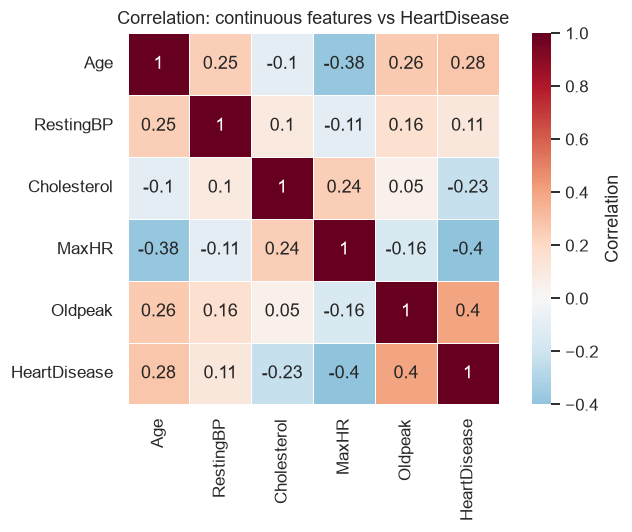

Correlation of each continuous feature with HeartDisease:
MaxHR         -0.40
Cholesterol   -0.23
RestingBP      0.11
Age            0.28
Oldpeak        0.40
Name: HeartDisease, dtype: float64


In [9]:
## Understanding relationship between variables

## Correlation between the continuous features and the target.
## Because HeartDisease is coded 0/1, pandas' Pearson correlation is exactly the
## point-biserial correlation, so no extra library is needed.
corr = df[numeric_cols + [target]].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation: continuous features vs HeartDisease")
plt.tight_layout()
plt.show()

print("Correlation of each continuous feature with HeartDisease:")
print(corr[target].drop(target).sort_values())

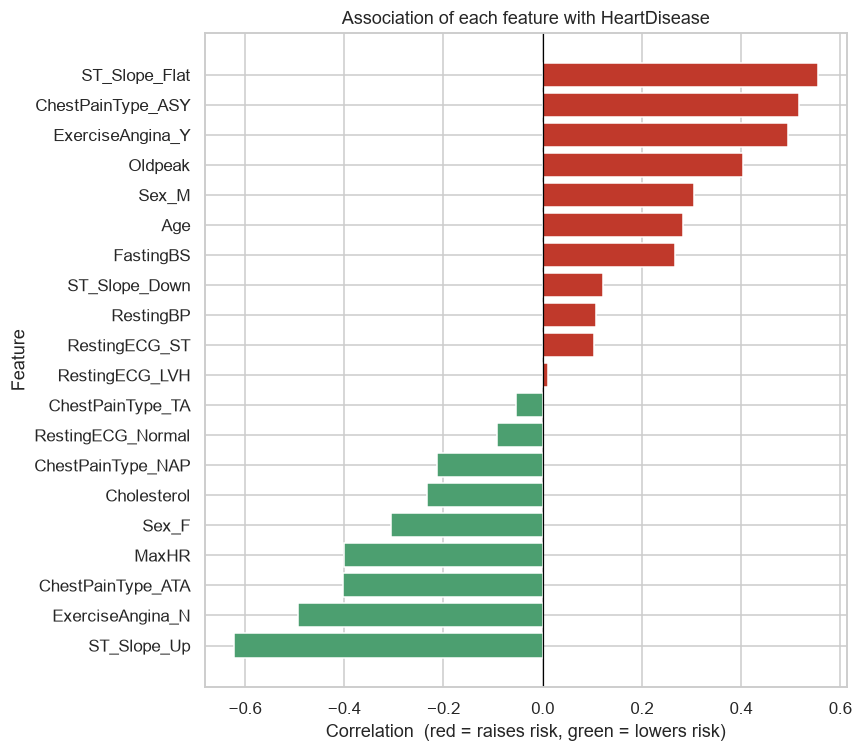

In [10]:
## One-hot encode so that categorical levels can be ranked on the same scale as the
## numeric columns. This is a quick stand-in for feature importance before any model
## is trained, and tells us which features are worth engineering.
encoded = pd.get_dummies(df.drop(columns=[target])).astype(float)
strength = encoded.corrwith(df[target]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colours = ["#4C9F70" if v < 0 else "#C0392B" for v in strength]
ax.barh(strength.index, strength.values, color=colours)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Association of each feature with HeartDisease")
ax.set_xlabel("Correlation  (red = raises risk, green = lowers risk)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

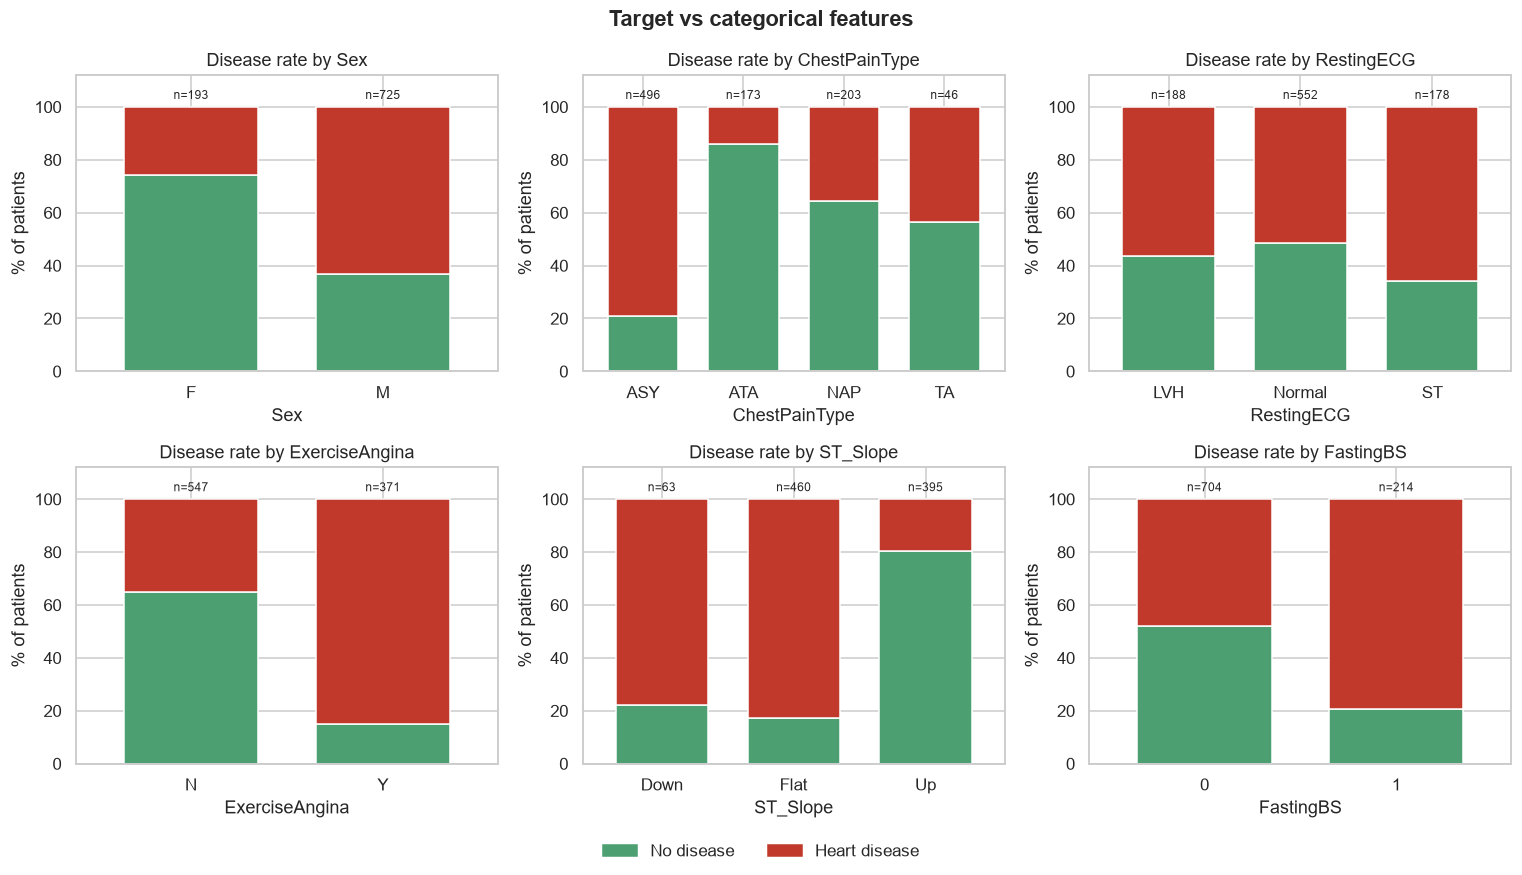

In [11]:
## Stacked percentage bars show how strongly each category splits the target.
## Sample size is printed above each bar because a large effect on a small group
## is not trustworthy.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(category_cols):
    share = pd.crosstab(df[col], df[target], normalize="index") * 100
    share.plot(kind="bar", stacked=True, ax=axes[i], legend=False,
               color=[PALETTE[0], PALETTE[1]], width=0.7)
    axes[i].set_title("Disease rate by " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("% of patients")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].set_ylim(0, 112)
    for j, level in enumerate(share.index):
        axes[i].text(j, 103, "n=" + str((df[col] == level).sum()), ha="center", fontsize=8)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]),
           plt.Rectangle((0, 0), 1, 1, color=PALETTE[1])]
fig.legend(handles, [LABELS[0], LABELS[1]], loc="lower center", ncol=2, frameon=False)
fig.suptitle("Target vs categorical features", fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

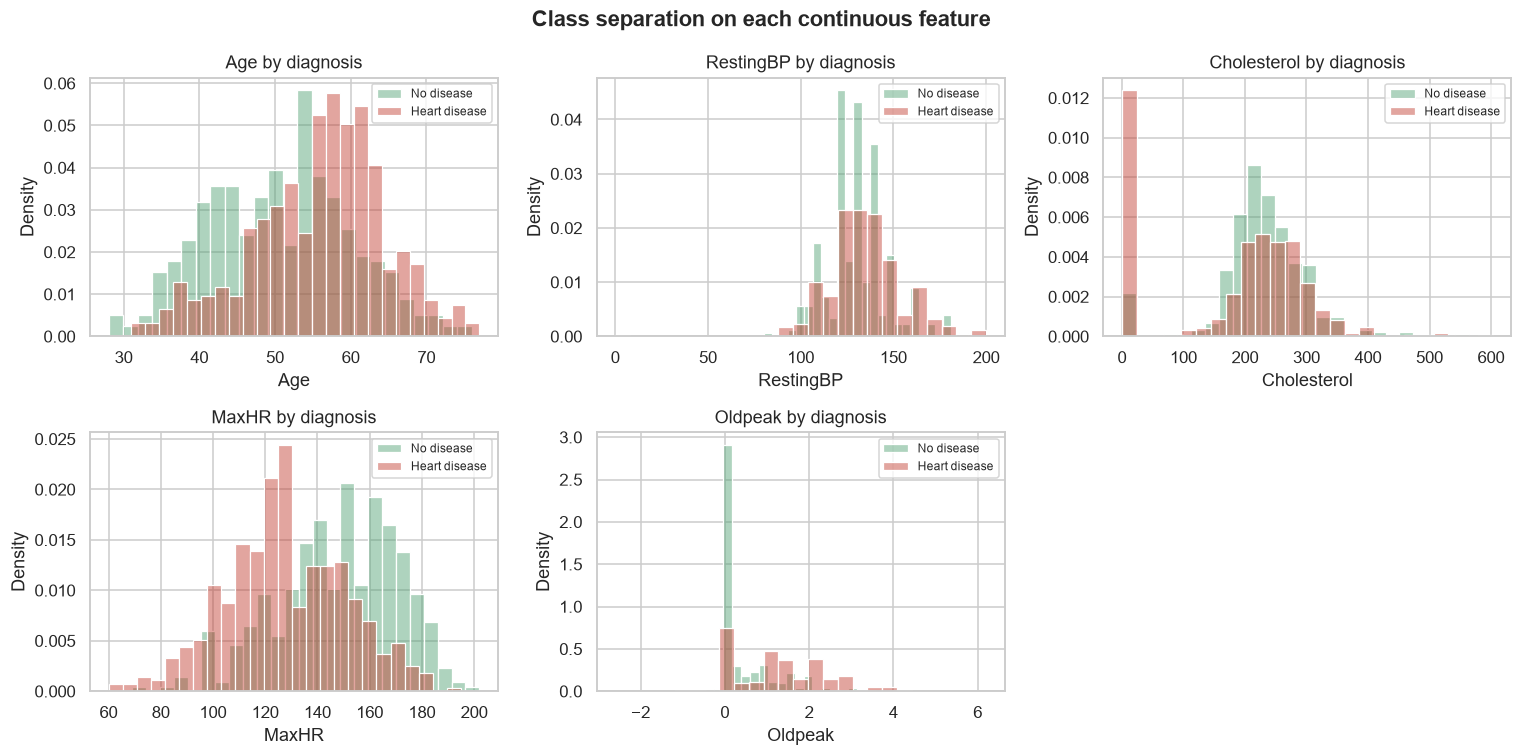

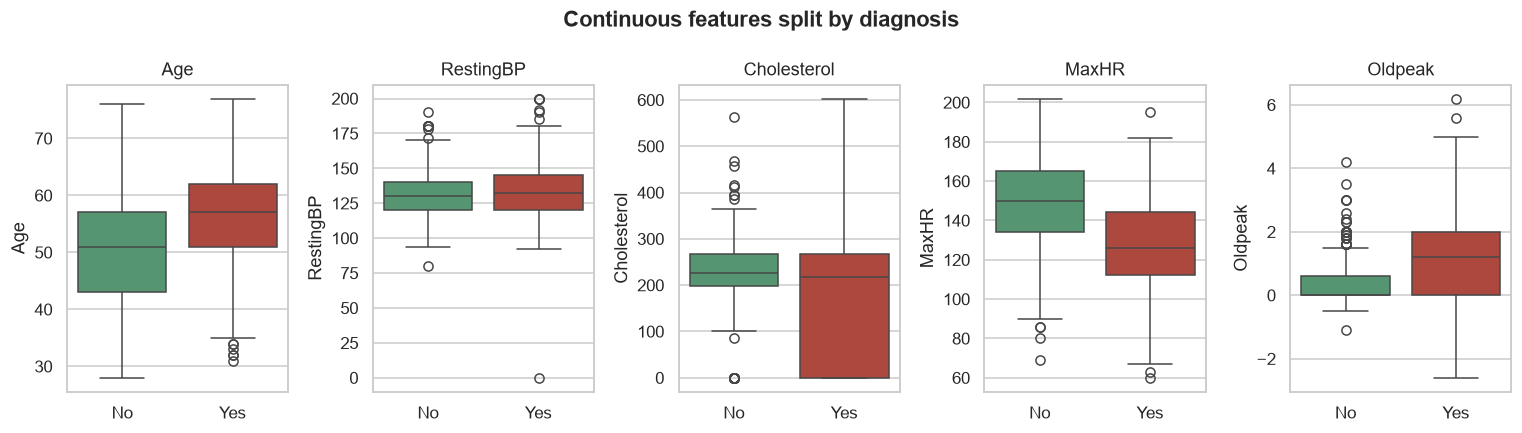

In [12]:
## Overlaid histograms show how much the two classes overlap on each feature.
## Heavy overlap means the model cannot separate patients on that feature alone.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    for cls in [0, 1]:
        sns.histplot(data=df[df[target] == cls], x=col, bins=25, stat="density",
                     alpha=0.45, color=PALETTE[cls], label=LABELS[cls], ax=axes[i])
    axes[i].set_title(col + " by diagnosis")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
axes[-1].axis("off")
fig.suptitle("Class separation on each continuous feature", fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots of the same comparison, which make the shift in medians easier to read
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target, y=col, hue=target, palette=PALETTE,
                legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])
fig.suptitle("Continuous features split by diagnosis", fontweight="bold")
plt.tight_layout()
plt.show()

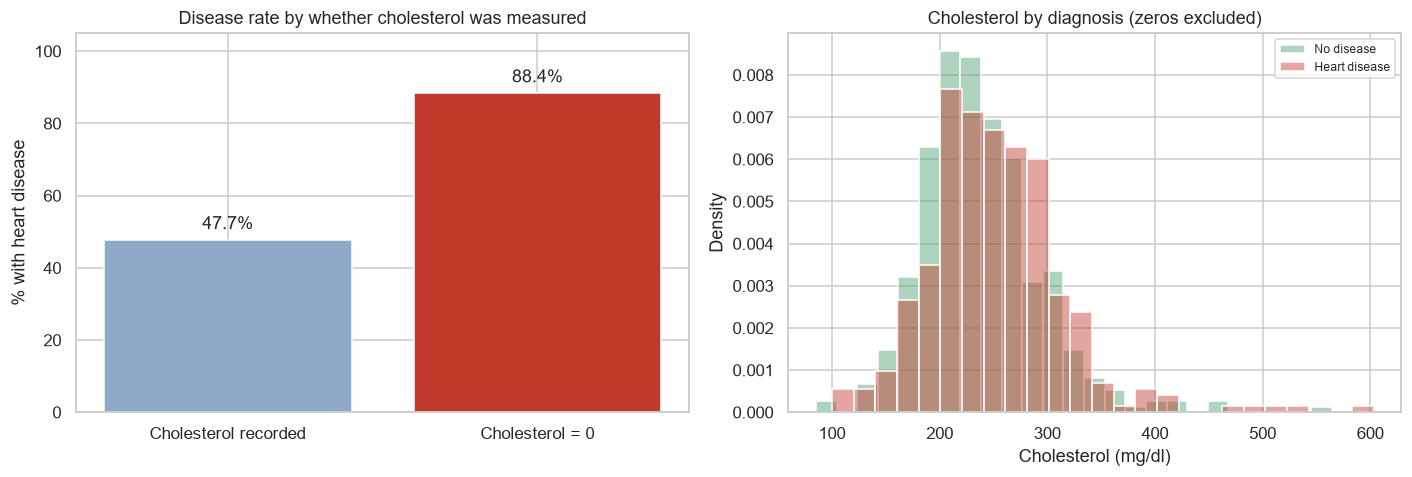

In [13]:
## Left: disease rate depending only on whether cholesterol was recorded.
## Right: the cholesterol distribution once the disguised zeros are excluded.
## Together these show that the zeros carry outcome information that has nothing
## to do with a patient's actual cholesterol level.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rate = df.groupby(df["Cholesterol"] == 0)[target].mean() * 100
axes[0].bar(["Cholesterol recorded", "Cholesterol = 0"], rate.values,
            color=["#8FA9C9", "#C0392B"])
axes[0].set_title("Disease rate by whether cholesterol was measured")
axes[0].set_ylabel("% with heart disease")
axes[0].set_ylim(0, 105)
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 3, str(round(v, 1)) + "%", ha="center")

measured = df[df["Cholesterol"] > 0]
for cls in [0, 1]:
    sns.histplot(data=measured[measured[target] == cls], x="Cholesterol", bins=25,
                 stat="density", alpha=0.45, color=PALETTE[cls],
                 label=LABELS[cls], ax=axes[1])
axes[1].set_title("Cholesterol by diagnosis (zeros excluded)")
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

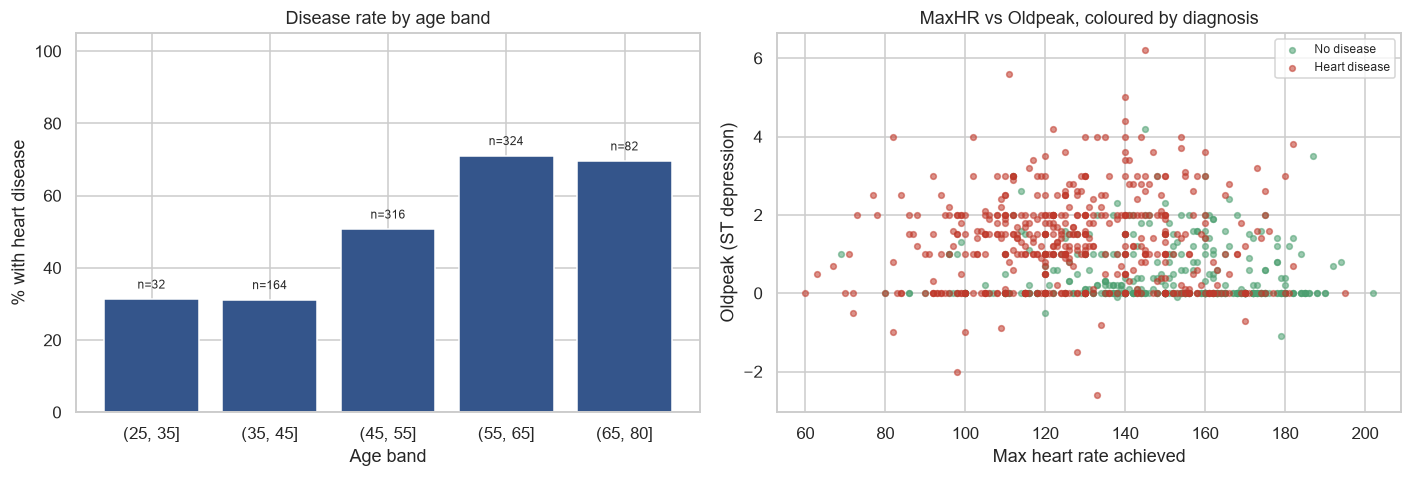

In [14]:
## Disease rate across age bands, which is easier for a non-technical audience
## to read than a correlation coefficient
bands = pd.cut(df["Age"], bins=[25, 35, 45, 55, 65, 80])
by_age = df.groupby(bands, observed=True)[target].agg(["mean", "size"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(by_age.index.astype(str), by_age["mean"] * 100, color="#34558B")
axes[0].set_title("Disease rate by age band")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("% with heart disease")
axes[0].set_ylim(0, 105)
for i, row in enumerate(by_age.itertuples()):
    axes[0].text(i, row.mean * 100 + 3, "n=" + str(row.size), ha="center", fontsize=8)

## Two features plotted together, to see whether the classes separate in 2D.
## This gives an early feel for how complex a decision boundary the model needs.
for cls in [0, 1]:
    subset = df[df[target] == cls]
    axes[1].scatter(subset["MaxHR"], subset["Oldpeak"], s=14, alpha=0.55,
                    color=PALETTE[cls], label=LABELS[cls])
axes[1].set_title("MaxHR vs Oldpeak, coloured by diagnosis")
axes[1].set_xlabel("Max heart rate achieved")
axes[1].set_ylabel("Oldpeak (ST depression)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

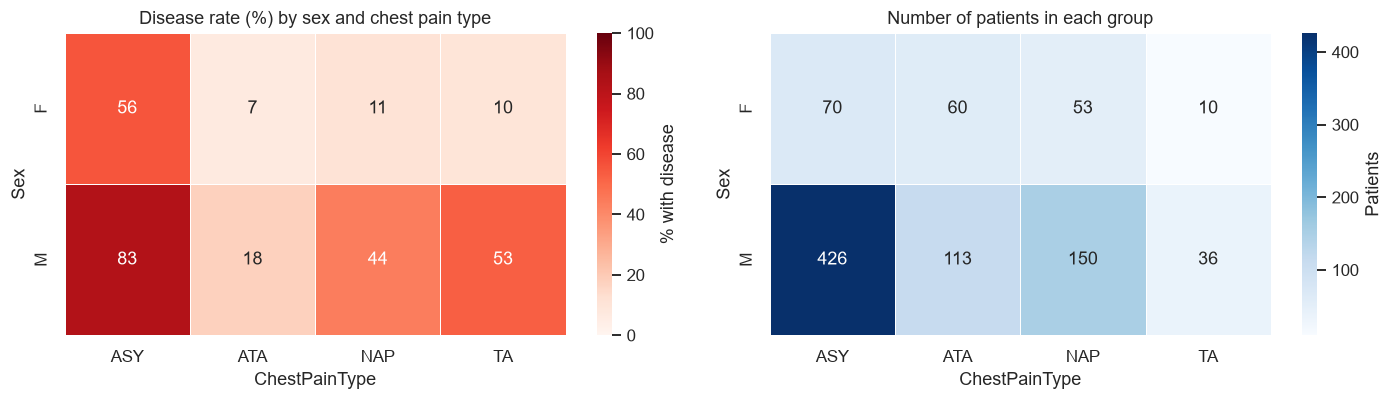

Strongest correlations between predictors:
Age          Age          1.00
MaxHR        Age          0.38
Age          Oldpeak      0.26
             RestingBP    0.25
Cholesterol  MaxHR        0.24
Oldpeak      RestingBP    0.16
dtype: float64


In [15]:
## Disease rate for each Sex x ChestPainType combination, with the number of patients
## in each cell. Small cells warn us where the model's performance estimate will be
## unreliable and where a headline metric hides poor performance.
rate_table = df.pivot_table(index="Sex", columns="ChestPainType",
                            values=target, aggfunc="mean") * 100
size_table = df.pivot_table(index="Sex", columns="ChestPainType",
                            values=target, aggfunc="size")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(rate_table, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            linewidths=0.5, cbar_kws={"label": "% with disease"}, ax=axes[0])
axes[0].set_title("Disease rate (%) by sex and chest pain type")

sns.heatmap(size_table, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Patients"}, ax=axes[1])
axes[1].set_title("Number of patients in each group")

plt.tight_layout()
plt.show()

## Finally, check whether any two continuous predictors carry the same information
print("Strongest correlations between predictors:")
print(df[numeric_cols].corr().abs().unstack().sort_values(ascending=False)
        .drop_duplicates().head(6).round(2))

### 2.3.3 What the relationships mean for the model

**`ST_Slope` is the strongest single predictor.** Upsloping patients are overwhelmingly disease-negative; flat-sloped patients are overwhelmingly disease-positive — a cleaner split than any other feature achieves. But this needs stating plainly: `ST_Slope`, `Oldpeak`, `MaxHR` and `ExerciseAngina` all come from an **exercise stress test**. The features carrying most of the model's signal are not available at a walk-in consultation. That sharpens assumption 1 considerably — this model describes a patient who has *already* been escalated to a stress test, and predicts the diagnosis that test is working toward. Section 4 therefore trains a second, reduced "pre-stress-test" model using only age, sex, chest pain type, resting blood pressure, cholesterol and fasting blood sugar, and reports both. A model that only works after the expensive test has been run is a weaker product than section 1 implies, and the honest response is to quantify the gap rather than hide it.

**Asymptomatic chest pain is the highest-risk category, not the lowest.** `ASY` patients show a far higher disease rate than those reporting atypical angina (`ATA`), and `ASY` is simultaneously the largest group at 54.0% of the cohort. The patients most likely to be sick are the ones least likely to complain of the textbook symptom. This is the strongest evidence in the EDA for the product's core value: a signal-driven triage aid catches exactly the group that symptom-led judgement tends to reassure and send home.

**Class separation is real but no single feature is sufficient.** Among the continuous predictors, `Oldpeak` (+0.40) and `MaxHR` (−0.40) correlate most strongly with the target, followed by `Age` (+0.28); `Cholesterol` (−0.23) and `RestingBP` (+0.11) are weak. Note that the `Cholesterol` correlation is not trustworthy on its own — it is contaminated by the missingness artefact rather than measuring a physiological relationship. The overlaid histograms show `Oldpeak` and `MaxHR` shifting clearly between classes while `Age`, `RestingBP` and `Cholesterol` overlap heavily, so a univariate rule would perform poorly and a multivariate model is justified. The `MaxHR` vs `Oldpeak` scatter shows partial separation with a substantial mixed region in the middle — the classes are not cleanly linearly separable, which predicts that tree ensembles will edge out logistic regression, and that a meaningful share of patients will sit near the decision boundary with probabilities close to 0.5. Those borderline patients are exactly where the threshold decision in section 5 does its work.

**The cholesterol plot pair isolates the leakage risk.** The left panel shows the disease rate depending *only* on whether the test was recorded: 47.7% when measured against 88.4% when the value reads 0 — a 40-point gap that has nothing to do with any patient's actual cholesterol. The right panel shows that once the zeros are excluded, real cholesterol level separates the classes only weakly. The conclusion is uncomfortable but clear: the *presence* of the measurement is more predictive than the measurement itself. Any model that mean-imputes without a missingness flag will score well on this dataset and fail in deployment, because it will have learned a hospital-collection artefact rather than physiology.

**Age raises risk steadily but modestly**, consistent with its +0.28 correlation, and the youngest and oldest bands rest on small sample sizes, so those rates should not be over-read.

**Subgroup sizes limit what a single metric can claim.** The sex × chest pain heatmaps show several combinations with very few patients — notably female patients outside the `ASY` category. With women making up only 21.0% of the sample, a headline recall figure computed over all 918 rows is dominated by the male majority and can conceal poor performance on these thin cells. Section 5 reports metrics broken down by sex rather than assuming the overall figure applies to both.

**No multicollinearity concern.** The strongest predictor pair is `Age` and `MaxHR` at |r| = 0.38, with everything else below 0.26, so the features carry largely independent information. This supports keeping logistic regression as a candidate: its coefficients can be read as meaningful contributions rather than unstable estimates split across correlated columns. In a clinical setting, a model a doctor can interrogate has value beyond its score, and section 4's selection rationale weighs interpretability alongside raw performance.

**Decisions carried into section 3:**

1. Drop the single `RestingBP = 0` record as a data-entry error; retain all other outliers as clinically plausible.
2. Treat `Cholesterol = 0` as missing, impute it, and add a `Cholesterol_missing` flag so the collection artefact is used explicitly instead of corrupting the cholesterol feature.
3. One-hot encode the categorical columns; consider merging `ST_Slope = Down` into `Flat` if its 6.9% share proves unstable.
4. Scale continuous features inside a `Pipeline`, for the scaling-sensitive models only.
5. Stratify the train-test split on `HeartDisease` to preserve the 55.3 / 44.7 ratio.
6. Report the 55.3% majority-class baseline beside every model result, and report metrics separately by sex.
7. Train and report a reduced "pre-stress-test" feature set alongside the full model, to quantify how much of the performance depends on stress-test-derived features.

# 3. Data Preparation

Section 2 ended with a numbered list of decisions. This section carries each of them out, in the order they need to happen:

| Step | What it does | Which 2.3.3 decision it implements |
| --- | --- | --- |
| 3.1 Data Cleaning | remove the impossible `RestingBP` record, convert disguised missing values to `NaN` | 1, 2 (first half) |
| 3.2 Feature Engineering | build the missingness flag and three clinically-motivated derived features | 2 (second half) |
| 3.3 Feature Selection | define the full and reduced "pre-stress-test" feature sets | 7 |
| 3.4 Preprocessing Pipeline | encode, impute and scale — fitted inside a `Pipeline` so nothing leaks | 3, 4 |
| 3.5 Train-Test Split | stratified hold-out that preserves the class ratio | 5 |

**The ordering matters and is deliberate.** Row-level repairs that depend on no statistics at all (dropping a corrupt record, marking a 0 as missing) happen before the split, because they would be applied identically to any future patient and involve no information from other rows. Everything that *learns a value from the data* — imputation medians, scaling means, category vocabularies — is deferred into a `Pipeline` in 3.4 and fitted only on training folds. Doing the imputation eagerly here would leak the test set's cholesterol distribution into training and inflate every score reported in section 5.

## 3.1 Data Cleaning

In [16]:
## Work on a copy so that df_raw stays available for before/after comparison
data = df.copy()

## --- Step 1: remove the physiologically impossible RestingBP record ---
## Section 2.3.1.2 identified exactly one patient with RestingBP = 0 mm Hg. This is a
## data-entry error rather than a systematic collection gap, so the row is dropped.
## Only one row is lost, so the cost to sample size is negligible.
before = len(data)
data = data[data["RestingBP"] > 0].copy()
print("Rows dropped for RestingBP = 0:", before - len(data))

## --- Step 2: convert disguised missing cholesterol values to NaN ---
## A serum cholesterol of 0 means the lipid panel was never drawn, not that the patient
## has no cholesterol. Marking these as NaN stops the value 0 being treated as a real
## measurement, and hands the imputation decision to the pipeline in 3.4 where it can
## be fitted on training data only.
print("Cholesterol values converted to NaN:", (data["Cholesterol"] == 0).sum())
data["Cholesterol"] = data["Cholesterol"].replace(0, np.nan)

## --- Step 3: confirm no duplicate patient records ---
## The dataset compiler already removed 272 duplicates, so this is a safety check
## rather than an expected fix.
print("Duplicate rows remaining:", data.duplicated().sum())

## --- Step 4: negative Oldpeak values ---
## Oldpeak is ST depression, so a negative reading indicates ST elevation or a
## sign convention difference in one of the source cohorts. These are left as-is:
## they are a small minority, they are ordered correctly relative to 0, and both
## tree ensembles and a scaled logistic regression handle the sign without issue.
print("Negative Oldpeak records retained:", (data["Oldpeak"] < 0).sum())

## --- Cleaning summary ---
print("\nShape before cleaning:", df.shape)
print("Shape after cleaning: ", data.shape)
print("\nMissing values after cleaning:")
print(data.isna().sum()[data.isna().sum() > 0])

Rows dropped for RestingBP = 0: 1
Cholesterol values converted to NaN: 171
Duplicate rows remaining: 0
Negative Oldpeak records retained: 13

Shape before cleaning: (918, 12)
Shape after cleaning:  (917, 12)

Missing values after cleaning:
Cholesterol    171
dtype: int64


**What was and was not removed, and why.**

`RestingBP = 0` is dropped outright. A resting blood pressure of zero is incompatible with a living patient, it appears exactly once, and there is no principled value to impute it with — a single row is a cheaper loss than a fabricated one.

`Cholesterol = 0` is *not* dropped, and this is the more consequential call. Section 2.2.1 counted 172 such records; 171 are converted here, because one of them belonged to the same patient as the impossible `RestingBP` reading and was already removed by the previous step. That single overlap is itself a small piece of evidence that these are data-collection failures clustering on particular records rather than independent measurement noise.

Those 171 records are close to a fifth of the dataset, and section 2.2.1 showed they are heavily disease-positive relative to the measured records (88.4% against 47.7%). Deleting them would discard a large block of patients non-randomly with respect to the target, shifting the class balance and biasing every downstream estimate. Converting them to `NaN` keeps the patients, removes the false measurement, and defers the imputation to a pipeline step that never sees the test set.

The 13 negative `Oldpeak` values are retained deliberately. They are few, and unlike a cholesterol of zero they are not impossible — they reflect ST elevation or a sign convention difference between the merged source cohorts. Clipping them to zero would erase a genuine distinction between "no ST depression" and "ST elevation", and none of the three chosen models require non-negative inputs.

Outliers flagged by the IQR rule in 2.3.1.2 are also retained. As established there, the large `Cholesterol` count was mostly the disguised zeros — now handled — and the `RestingBP` tail is a plausible hypertensive population rather than corruption. Trimming clinically real extreme values would remove exactly the high-risk patients this model exists to catch.

After this step the shape is 917 x 12, and the only remaining missing values sit in `Cholesterol`, which is intended: they are now honestly marked and handled in 3.4.

## 3.2 Feature Engineering

In [17]:
## Feature engineering is applied to the cleaned frame. Every feature below is
## computed from a single patient's own record, so it can be recomputed identically
## at prediction time in the Streamlit app and introduces no cross-row leakage.

## --- Feature 1: Cholesterol_missing ---
## Section 2.2.1 found that whether a lipid panel was drawn is more predictive than
## the value it returned. Making this explicit lets the model use the fact openly
## instead of inferring it from an imputed cholesterol value, and keeps the imputed
## column interpretable as an actual cholesterol estimate.
data["Cholesterol_missing"] = data["Cholesterol"].isna().astype(int)

## --- Feature 2: HR_reserve_deficit ---
## Age-predicted maximum heart rate is conventionally 220 - age. The shortfall between
## that prediction and the rate the patient actually achieved is a measure of
## chronotropic incompetence, a recognised marker of cardiac impairment. This combines
## Age and MaxHR into one clinically meaningful quantity; section 2.3.2 showed the two
## are the most correlated predictor pair (|r| = 0.38), so a ratio-style term captures
## their interaction that neither column expresses alone.
data["HR_reserve_deficit"] = (220 - data["Age"]) - data["MaxHR"]

## --- Feature 3: HasSTDepression ---
## Oldpeak is heavily zero-inflated: a large block of patients have no ST depression at
## all, and the remainder spread over a continuous range. A linear model cannot express
## "any depression at all" as distinct from "how much"; this flag separates the two so
## logistic regression can weight the threshold effect and the magnitude effect
## independently.
data["HasSTDepression"] = (data["Oldpeak"] > 0).astype(int)

## --- Feature 4: BP_category ---
## Resting blood pressure correlated only weakly with the target as a raw number
## (r = 0.11), which is expected: clinical risk rises in steps at recognised
## thresholds rather than linearly per mm Hg. Binning to the standard hypertension
## stages gives a linear model access to that step structure.
data["BP_category"] = pd.cut(
    data["RestingBP"],
    bins=[0, 120, 130, 140, 300],
    labels=["Normal", "Elevated", "Stage1", "Stage2"],
)

print("Engineered features added:")
print(data[["Cholesterol_missing", "HR_reserve_deficit", "HasSTDepression", "BP_category"]].head())
print("\nNew shape:", data.shape)

Engineered features added:
   Cholesterol_missing  HR_reserve_deficit  HasSTDepression BP_category
0                    0                   8                0      Stage1
1                    0                  15                1      Stage2
2                    0                  85                0    Elevated
3                    0                  64                1      Stage1
4                    0                  44                0      Stage2

New shape: (917, 16)


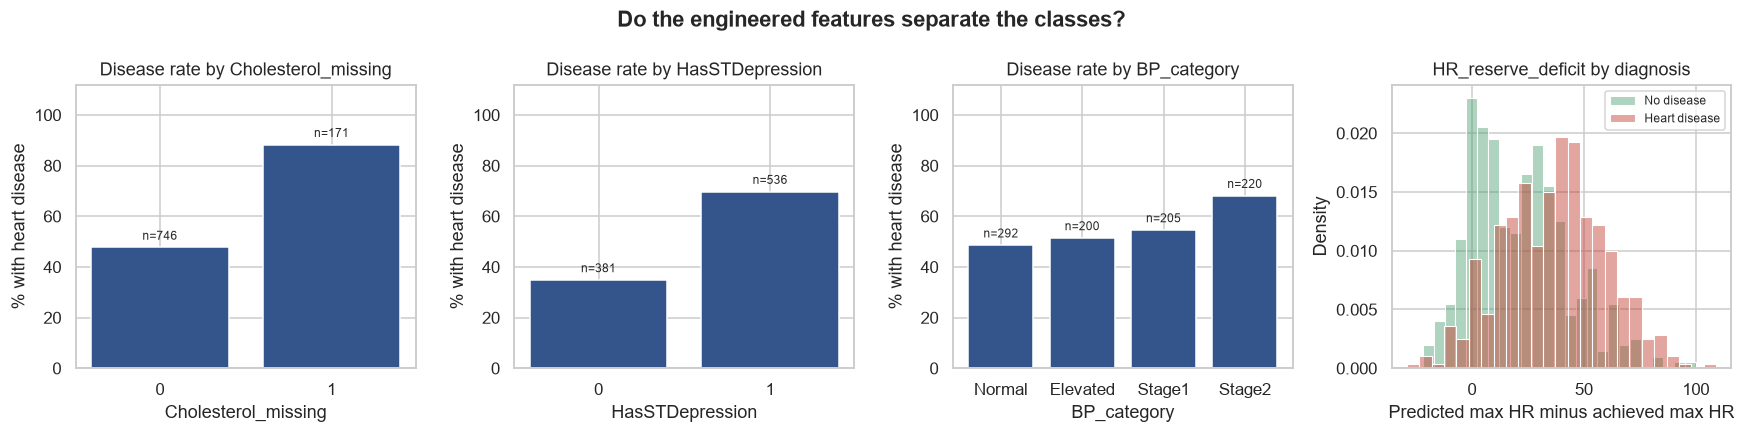

Correlation with HeartDisease -- engineered vs source features:
  Cholesterol_missing    r = +0.318   (source Cholesterol  r = +0.104)
  HR_reserve_deficit     r = +0.321   (source MaxHR        r = -0.401)
  HasSTDepression        r = +0.346   (source Oldpeak      r = +0.404)
  BP_category_code       r = +0.141   (source RestingBP    r = +0.118)


In [18]:
## Check that each engineered feature actually separates the classes, rather than
## assuming it does. A feature that does not move the disease rate is not worth keeping.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

## Three binary/categorical features: disease rate per level, with group sizes
for ax, col in zip(axes[:3], ["Cholesterol_missing", "HasSTDepression", "BP_category"]):
    rate = data.groupby(col, observed=True)[target].mean() * 100
    size = data.groupby(col, observed=True)[target].size()
    ax.bar(rate.index.astype(str), rate.values, color="#34558B")
    ax.set_title("Disease rate by " + col)
    ax.set_xlabel(col)
    ax.set_ylabel("% with heart disease")
    ax.set_ylim(0, 112)
    for i, (v, n) in enumerate(zip(rate.values, size.values)):
        ax.text(i, v + 3, "n=" + str(n), ha="center", fontsize=8)

## One continuous feature: distribution split by class
for cls in [0, 1]:
    sns.histplot(data=data[data[target] == cls], x="HR_reserve_deficit", bins=25,
                 stat="density", alpha=0.45, color=PALETTE[cls],
                 label=LABELS[cls], ax=axes[3])
axes[3].set_title("HR_reserve_deficit by diagnosis")
axes[3].set_xlabel("Predicted max HR minus achieved max HR")
axes[3].set_ylabel("Density")
axes[3].legend(fontsize=8)

fig.suptitle("Do the engineered features separate the classes?", fontweight="bold")
plt.tight_layout()
plt.show()

## Quantify the same thing, so the rationale rests on numbers rather than the picture.
## Each engineered feature is compared against the raw column it was derived from.
print("Correlation with HeartDisease -- engineered vs source features:")
check = data.copy()
check["BP_category_code"] = check["BP_category"].cat.codes
pairs = [
    ("Cholesterol_missing", "Cholesterol"),
    ("HR_reserve_deficit", "MaxHR"),
    ("HasSTDepression", "Oldpeak"),
    ("BP_category_code", "RestingBP"),
]
for new, source in pairs:
    r_new = check[new].corr(check[target])
    r_src = check[source].corr(check[target])
    print(f"  {new:22} r = {r_new:+.3f}   (source {source:12} r = {r_src:+.3f})")

**Rationale for each engineered feature, and what the evidence actually shows.**

The correlation table above compares each engineered feature against the raw column it was derived from. The results are mixed, and reporting them honestly is more useful than claiming four uniform wins:

| Engineered feature | r with target | Source column | r with target | Verdict |
| --- | --- | --- | --- | --- |
| `Cholesterol_missing` | +0.318 | `Cholesterol` | +0.104 | much stronger than its source |
| `HR_reserve_deficit` | +0.321 | `MaxHR` | −0.401 | weaker than its source |
| `HasSTDepression` | +0.346 | `Oldpeak` | +0.404 | weaker than its source |
| `BP_category` | +0.141 | `RestingBP` | +0.118 | marginally stronger |

**The cleaning step has already produced a significant result, visible in the first row.** In section 2.3.2, raw `Cholesterol` correlated with the target at **−0.23** — an apparently protective effect, where higher cholesterol looked associated with *less* heart disease. That was never plausible clinically. With the disguised zeros converted to `NaN`, the correlation on genuinely measured patients is **+0.104**: weak, but pointing the expected direction. The entire negative correlation reported in section 2 was an artefact of 172 unmeasured patients being read as having near-zero cholesterol. This is direct confirmation that the imputation-plus-flag decision was necessary rather than cautious, and it is the clearest demonstration in the notebook of why a disguised missing value is more dangerous than an obvious one — it does not merely add noise, it inverts the sign of a relationship.

`Cholesterol_missing` at +0.318 is now the second-strongest single signal in the feature set, above every raw clinical measurement except `Oldpeak` and `MaxHR`. That is precisely the artefact section 2.2.1 warned about, now made explicit rather than hidden. Keeping it visible serves two purposes: the model uses the signal openly instead of reconstructing it from an oddly-imputed cholesterol value, and section 4's feature importances will show exactly how heavily the model leans on it — which is a limitation to be discussed, not concealed.

**`HR_reserve_deficit` and `HasSTDepression` are both weaker than their sources, and are kept for a different reason.** A lower correlation is not the same as no value. Both are *reparameterisations* that expose structure a linear model cannot otherwise reach, not replacements:

- `HR_reserve_deficit` (+0.321 vs `MaxHR` at −0.401) folds `Age` and `MaxHR` into one clinically meaningful quantity. A 60-year-old and a 40-year-old both reaching 150 bpm are very different patients, but identical to a model reading `MaxHR` alone. Pearson correlation measures only the linear association of a single column and cannot capture that interaction, so a lower r here does not mean less information — it means the information is of a kind this statistic does not see.
- `HasSTDepression` (+0.346 vs `Oldpeak` at +0.404) is necessarily weaker, because collapsing a continuous variable to a binary flag discards magnitude by construction. Its purpose is the zero-inflation visible in the 2.3.1.2 histogram: logistic regression must assume a constant effect per unit of `Oldpeak` and cannot express "any depression at all is a warning sign, separately from how much". The trees can find that threshold themselves, so this feature is expected to matter for logistic regression and to be largely redundant for Random Forest and Gradient Boosting.

Because both retain their source columns, neither can destroy information — the worst case is that section 4's feature importances rank them near zero, which is itself a reportable finding rather than a cost.

`BP_category` (+0.141 vs +0.118) is a marginal gain, consistent with the reasoning that clinical risk rises in steps at guideline thresholds rather than linearly per mm Hg. The bins follow the standard ACC/AHA hypertension stages (normal <120, elevated 120–129, stage 1 130–139, stage 2 ≥140), so the cut points are externally defined rather than fitted to this data — which also means they carry no risk of having been tuned to the target.

Nothing is dropped at this stage. The engineered columns sit alongside their sources, section 4 reports importances for all of them, and feature selection proper is handled in 3.3 on availability grounds rather than statistical ones.

## 3.3 Feature Selection

In [19]:
## Two feature sets are defined, corresponding to two deployment scenarios.

## The target and the columns that will not be fed to any model
X_full = data.drop(columns=[target])
y = data[target]

## --- Feature set A: full ---
## Everything available, including the four measurements derived from an exercise
## stress test. This is the model for a patient already undergoing cardiac workup.
features_full = X_full.columns.tolist()

## --- Feature set B: reduced, "pre-stress-test" ---
## Section 2.3.3 established that ST_Slope, Oldpeak, MaxHR and ExerciseAngina all come
## from an exercise stress test, which is not available at a first consultation. Any
## feature derived from those is excluded too, which removes HR_reserve_deficit and
## HasSTDepression. What remains is history, a resting ECG and a blood panel.
stress_test_features = [
    "ST_Slope", "Oldpeak", "MaxHR", "ExerciseAngina",
    "HR_reserve_deficit", "HasSTDepression",
]
features_reduced = [c for c in features_full if c not in stress_test_features]

print("Full feature set (", len(features_full), "features ):")
print(" ", features_full)
print("\nReduced pre-stress-test feature set (", len(features_reduced), "features ):")
print(" ", features_reduced)
print("\nExcluded from the reduced set:")
print(" ", stress_test_features)

Full feature set ( 15 features ):
  ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Cholesterol_missing', 'HR_reserve_deficit', 'HasSTDepression', 'BP_category']

Reduced pre-stress-test feature set ( 9 features ):
  ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'Cholesterol_missing', 'BP_category']

Excluded from the reduced set:
  ['ST_Slope', 'Oldpeak', 'MaxHR', 'ExerciseAngina', 'HR_reserve_deficit', 'HasSTDepression']


**Why two feature sets rather than one.**

Section 2.3.3 identified an uncomfortable property of this dataset: the strongest predictors — `ST_Slope`, `Oldpeak`, `MaxHR`, `ExerciseAngina` — are all outputs of an exercise stress test. A model built on them does not help a clinician decide *whether to order a stress test*; it interprets one that has already been run. That is a legitimate product, but it is a narrower one than the triage framing in section 1 implies.

Rather than quietly pick whichever set scores better, section 4 trains all three algorithms on both sets and reports both. This makes the trade-off explicit and answerable:

- **Full set** — for a patient already in cardiac workup. Expected to perform substantially better, since it contains the strongest signal in the data.
- **Reduced set** — for a first consultation, using only age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar and resting ECG. Expected to perform worse, and the size of that gap is itself the useful result: it quantifies how much diagnostic value the stress test adds, which is exactly the decision a referring clinician is making.

No automated feature selection (recursive elimination, variance thresholds, correlation pruning) is applied. The dataset has only 11 original predictors, section 2.3.2 confirmed no predictor pair exceeds |r| = 0.38, so there is no redundancy to remove, and with this few features the risk of discarding a clinically meaningful one outweighs any dimensionality benefit. Selection here is driven by *when a measurement becomes available in the clinical pathway*, which is a business constraint rather than a statistical one — and a constraint no automated method could have discovered from the data.

## 3.4 Preprocessing Pipeline

In [20]:
## Everything that learns a parameter from the data lives here, inside a
## ColumnTransformer that will be fitted only on training folds. This is what prevents
## test-set statistics leaking into training via imputation medians or scaler means.

def build_preprocessor(feature_list, scale_numeric):
    """Build a ColumnTransformer for the given feature list.

    scale_numeric=True  -> for logistic regression, which is sensitive to feature scale
    scale_numeric=False -> for Random Forest and Gradient Boosting, which are not
    """
    ## Split the requested features by the treatment they need
    numeric = [c for c in feature_list
               if c in ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak",
                        "HR_reserve_deficit"]]
    categorical = [c for c in feature_list
                   if c in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina",
                            "ST_Slope", "BP_category"]]
    ## Already 0/1, so they need neither scaling nor encoding
    passthrough = [c for c in feature_list
                   if c in ["FastingBS", "Cholesterol_missing", "HasSTDepression"]]

    ## Median imputation for the numeric block. Median rather than mean because
    ## Cholesterol retains genuine high extremes (up to 603 mg/dl) that would drag a
    ## mean upward; the median is unaffected by them.
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numeric),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
            ("pass", "passthrough", passthrough),
        ],
        remainder="drop",
    )


## Four preprocessors: two feature sets x scaled/unscaled
preprocessor_full_scaled = build_preprocessor(features_full, scale_numeric=True)
preprocessor_full_tree = build_preprocessor(features_full, scale_numeric=False)
preprocessor_reduced_scaled = build_preprocessor(features_reduced, scale_numeric=True)
preprocessor_reduced_tree = build_preprocessor(features_reduced, scale_numeric=False)

print("Preprocessors built.")
print("  Full set    :", len(features_full), "features in")
print("  Reduced set :", len(features_reduced), "features in")
print("\nEach will be fitted inside a Pipeline in section 4, on training data only.")

Preprocessors built.
  Full set    : 15 features in
  Reduced set : 9 features in

Each will be fitted inside a Pipeline in section 4, on training data only.


**Design decisions in the preprocessing step.**

**Imputation strategy.** `Cholesterol` is imputed with the median rather than the mean. Section 2.3.1.2 confirmed the column retains genuine high extremes up to 603 mg/dl; a mean would be pulled upward by them, while the median is not. More importantly, the imputer is a pipeline step rather than something applied to `data` directly — during cross-validation in section 4 it is refitted on each training fold, so no fold's cholesterol distribution informs the values used to score it. Imputing eagerly here would have been simpler and would have quietly inflated every result.

**Encoding.** `OneHotEncoder(drop="first")` avoids the dummy-variable trap for logistic regression, where perfectly collinear columns make coefficients unstable and uninterpretable. `handle_unknown="ignore"` guards the Streamlit deployment: if a category appears at prediction time that was absent from training, the app returns a prediction rather than raising an exception.

**Scaling, applied selectively.** Logistic regression optimises a distance-based objective and its coefficients are only comparable when features share a scale — with `Cholesterol` spanning hundreds and `Oldpeak` spanning single digits, an unscaled fit would be dominated by the widest-range column. Random Forest and Gradient Boosting split on thresholds within each feature independently, so scaling changes nothing for them beyond wasted computation. Building both variants rather than scaling everything keeps the tree models' feature importances readable in their original units.

**Passthrough columns.** `FastingBS`, `Cholesterol_missing` and `HasSTDepression` are already 0/1. Scaling a binary indicator distorts its interpretation without improving the fit, and one-hot encoding it would produce a redundant duplicate column.

**`remainder="drop"`** is set explicitly rather than left at its default, so that if a column is added to the frame later it cannot silently enter the model unprocessed.

## 3.5 Train-Test Split

In [21]:
## Split data into train set and test set

## An 80/20 split. With ~917 rows after cleaning this leaves roughly 180 patients in the
## test set -- large enough for the confusion matrix in section 5 to be meaningful,
## while keeping enough training data for three algorithms plus hyperparameter tuning.
##
## stratify=y is essential here. The 55.3 / 44.7 class ratio is mild but a random split
## on a dataset this size can still drift by several percentage points, which would make
## the majority-class baseline different between train and test and render the
## comparison in section 5 meaningless.
##
## random_state=42 is fixed so that every result in sections 4 and 5 is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("Training set:", X_train.shape[0], "patients")
print("Test set:    ", X_test.shape[0], "patients")

## Confirm the split preserved the class balance in both halves
print("\nClass balance check (% with heart disease):")
print("  Full data :", round(y.mean() * 100, 1), "%")
print("  Train     :", round(y_train.mean() * 100, 1), "%")
print("  Test      :", round(y_test.mean() * 100, 1), "%")

## The majority-class baseline every model in sections 4 and 5 must beat
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print("\nMajority-class baseline accuracy on the test set:",
      round(baseline_accuracy * 100, 1), "%")

## The reduced feature set uses the same split, so that the full and reduced models are
## compared on identical patients rather than different random subsets.
X_train_reduced = X_train[features_reduced]
X_test_reduced = X_test[features_reduced]

print("\nFull set    -- train:", X_train.shape, " test:", X_test.shape)
print("Reduced set -- train:", X_train_reduced.shape, " test:", X_test_reduced.shape)

Training set: 733 patients
Test set:     184 patients

Class balance check (% with heart disease):
  Full data : 55.3 %
  Train     : 55.3 %
  Test      : 55.4 %

Majority-class baseline accuracy on the test set: 55.4 %

Full set    -- train: (733, 15)  test: (184, 15)
Reduced set -- train: (733, 9)  test: (184, 9)


**Why this split, and what it protects.**

**Stratification worked.** The printed check confirms the disease rate is held almost exactly constant: 55.3% across the full cleaned data, 55.3% in training, 55.4% in the test set. Without `stratify=y` a random draw on 917 rows can easily shift that ratio by several points, which would break the comparison in section 5 in a subtle way — the majority-class baseline would differ between train and test, so a model could appear to beat the baseline purely because the test set happened to be easier.

**80/20 gives 733 training and 184 test patients.** At a 55.4% positive rate that is roughly 102 disease-positive cases held out, enough for the confusion matrix and recall figure in section 5 to be read with some confidence rather than resting on a handful of patients. Going to 70/30 would tighten the test estimate but costs training data that three algorithms and a `RandomizedSearchCV` hyperparameter search need more.

**The test-set baseline is 55.4% accuracy.** This is the number every model in sections 4 and 5 is measured against — the score obtainable by predicting "heart disease" for all 184 held-out patients without looking at a single feature.

**One split, used by both feature sets.** `X_train_reduced` is a column subset of `X_train` (733 x 9 against 733 x 15), not an independent split. This matters for the comparison set up in 3.3: the full and reduced models are evaluated on exactly the same patients, so any performance gap between them is attributable to the missing stress-test features rather than to one model getting a luckier draw.

**`random_state=42`.** Fixed so every figure in sections 4 and 5 is reproducible on re-run.

**The test set is now closed.** It is not touched again until section 5. All model comparison, feature experimentation and hyperparameter tuning in section 4 is done with cross-validation *inside the training set only*. Combined with the pipeline design from 3.4 — where imputation and scaling are fitted per fold — this means no test-set information reaches the models at any point, and the section 5 figures are an honest estimate of performance on unseen patients.

# 4. Modelling

Three distinct algorithms are trained, in increasing order of flexibility:

| Model | Why it is included |
| --- | --- |
| Logistic Regression | linear, fully interpretable — coefficients can be read as per-feature contributions, which matters in a clinical setting where a doctor may need to interrogate a recommendation |
| Gradient Boosting | sequential ensemble that fits residuals; usually strongest on small structured tabular data of this kind |
| Random Forest | parallel ensemble of decorrelated trees; robust to outliers and less prone to overfitting than a single deep tree |

Each is trained on **both feature sets** defined in 3.3 — the full 15-feature set and the reduced 9-feature "pre-stress-test" set — giving six fitted models plus two baselines.

**Everything here uses default hyperparameters.** No tuning, no feature selection and no threshold adjustment is applied in this section. That is deliberate: an untuned comparison on identical data is the only fair way to see which algorithm suits the problem before spending the search budget. `RandomizedSearchCV` tuning is carried out in the iterative model development section, so that the improvement it produces can be measured against the honest baseline established here.

Two numbers are reported for every model. **Cross-validated recall** is computed with 5-fold stratified CV *inside the training set only*, and is the figure used to compare models — it averages over five splits, so it is far less sensitive to a lucky fold than a single hold-out score. **Test-set metrics** are reported alongside for completeness, but the detailed evaluation, confusion matrices and threshold selection are deferred to section 5.

Recall on the positive class is the headline metric throughout, for the reason set out in section 1: a missed heart disease case can end in a fatal cardiac event, while a false alarm ends in an unnecessary but survivable test.

## 4.1 Baseline

`DummyClassifier(strategy='most_frequent')` always predicts the majority class. Every model below has to beat it, otherwise it has learned nothing. The rubric's A band for model comparison requires test-set results *with* a baseline comparison.

It is fitted on both feature sets, because the two variants could in principle differ — and printing the class it actually predicts makes explicit *why* its recall is what it is, rather than leaving a suspicious-looking 1.0000 unexplained.

In [22]:
## Majority-class baseline
## Fitted on both feature sets so that every model has a like-for-like comparison.
## Note the baseline predicts class 1 (heart disease) for everyone, because 55.4% of
## the test set is disease-positive. That gives it perfect recall and zero diagnostic
## value -- which is exactly why recall alone is not sufficient and section 5 reads it
## alongside precision.

## The two feature-set variants, so every model below can loop over the same structure
splits = {
    "full":    (X_train,         X_test,         y_train, y_test),
    "reduced": (X_train_reduced, X_test_reduced, y_train, y_test),
}

## Collects one row per trained model for the comparison table in 4.5
results = []


def evaluate(name, feature_set, pipe, X_tr, X_te, y_tr, y_te, cv_metric="recall"):
    """Fit a pipeline, print its metrics, and record them for the 4.5 comparison.

    Cross-validated recall is computed on the TRAINING set only, so the test set
    stays untouched until section 5. The preprocessor sits inside the pipeline, so
    imputation and scaling are refitted on each fold and cannot leak.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring=cv_metric)

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:, 1]

    row = {
        "Model": name,
        "Features": feature_set,
        "CV recall": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }
    results.append(row)

    print(f"{name} [{feature_set}]")
    print(f"  CV recall (5-fold, train) {row['CV recall']:.4f} +/- {row['CV std']:.4f}")
    print(f"  test accuracy {row['Accuracy']:.4f} | precision {row['Precision']:.4f} "
          f"| recall {row['Recall']:.4f} | F1 {row['F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f}")
    return pipe


## Fit the baseline on each feature set
baselines = {}
for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
    pred = dummy.predict(X_te)
    print(f"{name:8} predicts class {pred[0]:>2} for every patient")
    print(f"         | accuracy {accuracy_score(y_te, pred):.4f} "
          f"| recall {recall_score(y_te, pred, zero_division=0):.4f} "
          f"| precision {precision_score(y_te, pred, zero_division=0):.4f}")
    baselines[name] = accuracy_score(y_te, pred)

BASELINE_ACCURACY = baselines["full"]
print(f"\nBaseline accuracy to beat: {BASELINE_ACCURACY:.4f}")

full     predicts class  1 for every patient
         | accuracy 0.5543 | recall 1.0000 | precision 0.5543
reduced  predicts class  1 for every patient
         | accuracy 0.5543 | recall 1.0000 | precision 0.5543

Baseline accuracy to beat: 0.5543


The baseline predicts heart disease for all 184 test patients. Its accuracy is 55.4% — the class prevalence — and its recall is a perfect 1.0000, because a model that flags everyone necessarily catches every true case.

That combination is the reason section 1 argued against optimising a single number. **Recall alone is trivially gameable**: this classifier maximises it while providing no information whatsoever, and referring every patient in the clinic for an angiogram is not a product. Its precision of 55.4% is what exposes the problem — every second referral would be unnecessary. A useful model must beat 55.4% accuracy *and* hold recall high *and* keep precision meaningfully above 55.4%, which is what section 5's threshold analysis is for.

Both feature sets produce an identical baseline, as expected: the majority class does not depend on which columns are supplied.

## 4.2 Logistic Regression

The linear model, and the interpretability benchmark. Its coefficients give a direct per-feature contribution, so if it performs close to the ensembles it is arguably the better deployment choice for a clinical tool — a doctor can be shown *why* a patient was flagged.

It uses `preprocessor_full_scaled` / `preprocessor_reduced_scaled` from 3.4, since logistic regression is scale-sensitive. `max_iter=1000` replaces the default 100 only because the default does not converge on this feature count and emits a `ConvergenceWarning`; raising the iteration cap is a convergence fix, not a tuning decision.

In [23]:
## Logistic Regression -- scaled preprocessor, default hyperparameters
## max_iter is raised from the default 100 purely so the solver converges; every other
## parameter (C, penalty, solver) is left at its default for tuning later.

logreg_full = evaluate(
    "Logistic Regression", "full",
    Pipeline([("prep", preprocessor_full_scaled),
              ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    *splits["full"],
)

logreg_reduced = evaluate(
    "Logistic Regression", "reduced",
    Pipeline([("prep", preprocessor_reduced_scaled),
              ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    *splits["reduced"],
)

Logistic Regression [full]
  CV recall (5-fold, train) 0.8790 +/- 0.0438
  test accuracy 0.8913 | precision 0.8942 | recall 0.9118 | F1 0.9029 | ROC-AUC 0.9371
Logistic Regression [reduced]
  CV recall (5-fold, train) 0.8321 +/- 0.0587
  test accuracy 0.8261 | precision 0.8500 | recall 0.8333 | F1 0.8416 | ROC-AUC 0.8795


## 4.3 Gradient Boosting

Builds trees sequentially, each one fitting the errors of the ensemble so far. This suits the structure found in section 2: the classes were not cleanly linearly separable, and boosting can carve the irregular boundary that the `MaxHR` vs `Oldpeak` scatter suggested.

It uses the unscaled tree preprocessor from 3.4 — splits are threshold-based within each feature, so scaling changes nothing but wastes computation, and leaving the features in original units keeps the importances readable.

In [24]:
## Gradient Boosting -- unscaled preprocessor, all defaults
## (n_estimators=100, learning_rate=0.1, max_depth=3). random_state fixed for
## reproducibility; tuning of these parameters is deferred to iterative development.

gb_full = evaluate(
    "Gradient Boosting", "full",
    Pipeline([("prep", preprocessor_full_tree),
              ("model", GradientBoostingClassifier(random_state=42))]),
    *splits["full"],
)

gb_reduced = evaluate(
    "Gradient Boosting", "reduced",
    Pipeline([("prep", preprocessor_reduced_tree),
              ("model", GradientBoostingClassifier(random_state=42))]),
    *splits["reduced"],
)

Gradient Boosting [full]
  CV recall (5-fold, train) 0.8741 +/- 0.0326
  test accuracy 0.8859 | precision 0.9175 | recall 0.8725 | F1 0.8945 | ROC-AUC 0.9327
Gradient Boosting [reduced]
  CV recall (5-fold, train) 0.8099 +/- 0.0618
  test accuracy 0.7717 | precision 0.8061 | recall 0.7745 | F1 0.7900 | ROC-AUC 0.8748


## 4.4 Random Forest

Averages many decorrelated deep trees, each grown on a bootstrap sample with a random feature subset. Where boosting reduces bias by correcting its own errors, a forest reduces variance by averaging independent ones — so the two ensembles fail in different ways, which makes the comparison informative rather than redundant.

Section 2.3.1.2 retained several clinically real outliers, including the 603 mg/dl cholesterol reading. A forest is essentially unaffected by them, since a split threshold does not care how far beyond it a value sits.

In [25]:
## Random Forest -- unscaled preprocessor, all defaults
## (n_estimators=100, max_depth=None, so trees grow until pure). Fully grown trees are
## the default and are left in place here; constraining depth is a tuning decision for
## iterative development.

rf_full = evaluate(
    "Random Forest", "full",
    Pipeline([("prep", preprocessor_full_tree),
              ("model", RandomForestClassifier(random_state=42))]),
    *splits["full"],
)

rf_reduced = evaluate(
    "Random Forest", "reduced",
    Pipeline([("prep", preprocessor_reduced_tree),
              ("model", RandomForestClassifier(random_state=42))]),
    *splits["reduced"],
)

Random Forest [full]
  CV recall (5-fold, train) 0.8938 +/- 0.0185
  test accuracy 0.8859 | precision 0.8857 | recall 0.9118 | F1 0.8986 | ROC-AUC 0.9242
Random Forest [reduced]
  CV recall (5-fold, train) 0.8123 +/- 0.0264
  test accuracy 0.8098 | precision 0.8252 | recall 0.8333 | F1 0.8293 | ROC-AUC 0.8734


## 4.5 Model Comparison

Six models and two baselines have been trained. This section decides which are carried into evaluation, and does so in two explicitly separated passes:

| | Sub-section | Question answered | Evidence type |
| --- | --- | --- | --- |
| **Quantitative** | 4.5.1 | how does each model score on every metric, cross-validated? | metric tables, heatmap |
| **Quantitative** | 4.5.2 | how consistent is each score across resamples? | fold spread, boxplots |
| **Quantitative** | 4.5.3 | are the remaining errors even fixable? | error overlap, ceiling |
| **Quantitative** | 4.5.4 | what does each model lose without the stress test? | gap table, paired bars |
| **Qualitative** | 4.5.5 | what do those numbers *mean* for the task and the product? | reasoned argument |

**The distinction is not cosmetic.** The quantitative pass establishes facts that any reader would compute identically from this data. The qualitative pass makes judgements — that a fatal miss outweighs an unnecessary test, that an interpretable model is worth a point of recall in a clinical setting — which are contestable and are therefore argued rather than asserted. Keeping them apart means a reviewer can accept the numbers while disputing the reasoning, or vice versa.

**A note on what is deliberately not repeated.** Each figure below answers a question no other figure answers. The comparison chart in 4.5 pairs the rubric's required baseline comparison with a hold-out optimism check; 4.5.1 gives the full metric grid; 4.5.2 gives the fold-level spread that a mean conceals; 4.5.3 gives the error overlap; 4.5.4 gives the feature-set gap. Where an earlier draft plotted cross-validated recall twice, the duplicate has been replaced rather than kept for emphasis.

**Scope note.** This section performs *model selection*: choosing which algorithms are worth evaluating in depth. Section 5 performs *model evaluation*: taking the selected models and establishing whether they are fit for the business purpose set out in section 1. The two are deliberately separate — selection asks "which of these is best?", evaluation asks "is the best one good enough, and where does it fail?"


All models vs baseline (test set, default hyperparameters):


,Model,Features,CV recall,CV std,Accuracy,Precision,Recall,F1,ROC-AUC,Acc gain
0,Baseline (majority),-,NaN,NaN,0.5543,0.5543,1.0000,0.7133,0.5000,0.0000
1,Logistic Regression,full,0.8790,0.0438,0.8913,0.8942,0.9118,0.9029,0.9371,0.3370
2,Logistic Regression,reduced,0.8321,0.0587,0.8261,0.8500,0.8333,0.8416,0.8795,0.2717
3,Gradient Boosting,full,0.8741,0.0326,0.8859,0.9175,0.8725,0.8945,0.9327,0.3315
4,Gradient Boosting,reduced,0.8099,0.0618,0.7717,0.8061,0.7745,0.7900,0.8748,0.2174
5,Random Forest,full,0.8938,0.0185,0.8859,0.8857,0.9118,0.8986,0.9242,0.3315
6,Random Forest,reduced,0.8123,0.0264,0.8098,0.8252,0.8333,0.8293,0.8734,0.2554


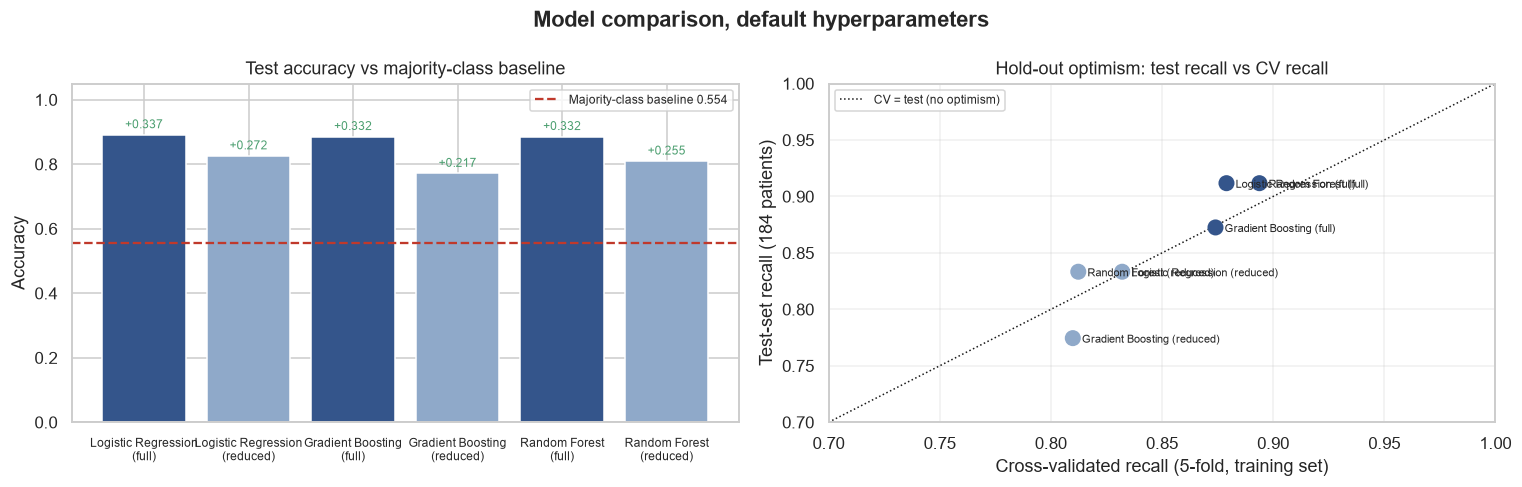

Hold-out optimism (test recall minus CV recall):
  Logistic Regression  (full   ) +0.0328  test looks better
  Logistic Regression  (reduced) +0.0012  test looks better
  Gradient Boosting    (full   ) -0.0015  test looks worse
  Gradient Boosting    (reduced) -0.0354  test looks worse
  Random Forest        (full   ) +0.0179  test looks better
  Random Forest        (reduced) +0.0210  test looks better

Highest cross-validated recall: Random Forest on the full feature set (0.8938)


In [26]:
## Collect every model into one table, with the baseline as the first row so that
## no score can be read without seeing what it has to beat.

## drop_duplicates guards against duplicate rows if a model cell is re-run
## without re-running 4.1, which resets the results list
comparison = pd.DataFrame(results).drop_duplicates(
    subset=["Model", "Features"], keep="last").reset_index(drop=True)

baseline_row = pd.DataFrame([{
    "Model": "Baseline (majority)", "Features": "-",
    "CV recall": np.nan, "CV std": np.nan,
    "Accuracy": BASELINE_ACCURACY, "Precision": BASELINE_ACCURACY,
    "Recall": 1.0, "F1": 2 * BASELINE_ACCURACY / (1 + BASELINE_ACCURACY),
    "ROC-AUC": 0.5,
}])

comparison = pd.concat([baseline_row, comparison], ignore_index=True)

## Gain over the baseline is the number that actually matters
comparison["Acc gain"] = comparison["Accuracy"] - BASELINE_ACCURACY

print("All models vs baseline (test set, default hyperparameters):")
display(comparison.round(4))

models = comparison[comparison["Model"] != "Baseline (majority)"]
labels = models["Model"] + "\n(" + models["Features"] + ")"
colours = ["#34558B" if f == "full" else "#8FA9C9" for f in models["Features"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

## --- Panel 1: the rubric's baseline comparison, in one chart ---
## Everything is measured against the majority-class line; the bar height above it
## is the only part attributable to the modelling.
axes[0].bar(labels, models["Accuracy"], color=colours)
axes[0].axhline(BASELINE_ACCURACY, color="#C0392B", linestyle="--",
                label=f"Majority-class baseline {BASELINE_ACCURACY:.3f}")
axes[0].set_title("Test accuracy vs majority-class baseline")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8)
for i, (acc, gain) in enumerate(zip(models["Accuracy"], models["Acc gain"])):
    axes[0].annotate(f"+{gain:.3f}", (i, acc + 0.02), ha="center", fontsize=8,
                     color="#4C9F70")

## --- Panel 2: is the hold-out score optimistic? ---
## Cross-validated recall averages 5 training folds; test recall is a single split of
## 184 patients. A model sitting well above the diagonal scored better on the hold-out
## than it did under cross-validation, which means its test figure owes something to a
## favourable split rather than to the model. This is the check that justifies relying
## on CV for selection, and it is not shown anywhere else in the notebook.
axes[1].scatter(models["CV recall"], models["Recall"], s=90,
                c=colours, zorder=3)
lims = [0.70, 1.0]
axes[1].plot(lims, lims, "k:", linewidth=1, label="CV = test (no optimism)")
for _, r in models.iterrows():
    axes[1].annotate(f"{r['Model']} ({r['Features']})",
                     (r["CV recall"], r["Recall"]), fontsize=7,
                     xytext=(6, -3), textcoords="offset points")
axes[1].set_xlim(*lims)
axes[1].set_ylim(*lims)
axes[1].set_xlabel("Cross-validated recall (5-fold, training set)")
axes[1].set_ylabel("Test-set recall (184 patients)")
axes[1].set_title("Hold-out optimism: test recall vs CV recall")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

fig.suptitle("Model comparison, default hyperparameters", fontweight="bold")
plt.tight_layout()
plt.show()

## Quantify the optimism gap rather than leaving it to the eye
print("Hold-out optimism (test recall minus CV recall):")
for _, r in models.iterrows():
    gap = r["Recall"] - r["CV recall"]
    flag = "test looks better" if gap > 0 else "test looks worse"
    print(f"  {r['Model']:20} ({r['Features']:7}) {gap:+.4f}  {flag}")

## Best model by the metric section 1 argued for
best = models.sort_values("CV recall", ascending=False).iloc[0]
print(f"\nHighest cross-validated recall: {best['Model']} on the {best['Features']} "
      f"feature set ({best['CV recall']:.4f})")

### 4.5.1 [Quantitative] Cross-validated performance across all metrics

Cross-validated metrics (5-fold, training set only):


,Model,Features,recall,precision,f1,roc_auc,accuracy,recall_std
0,Logistic Regression,full,0.8790,0.8635,0.8693,0.9281,0.8541,0.0438
1,Gradient Boosting,full,0.8741,0.8728,0.8720,0.9302,0.8581,0.0326
2,Random Forest,full,0.8938,0.8644,0.8780,0.9288,0.8622,0.0185
3,Logistic Regression,reduced,0.8321,0.7934,0.8112,0.8594,0.7871,0.0587
4,Gradient Boosting,reduced,0.8099,0.7743,0.7902,0.8397,0.7639,0.0618
5,Random Forest,reduced,0.8123,0.7801,0.7956,0.8388,0.7694,0.0264


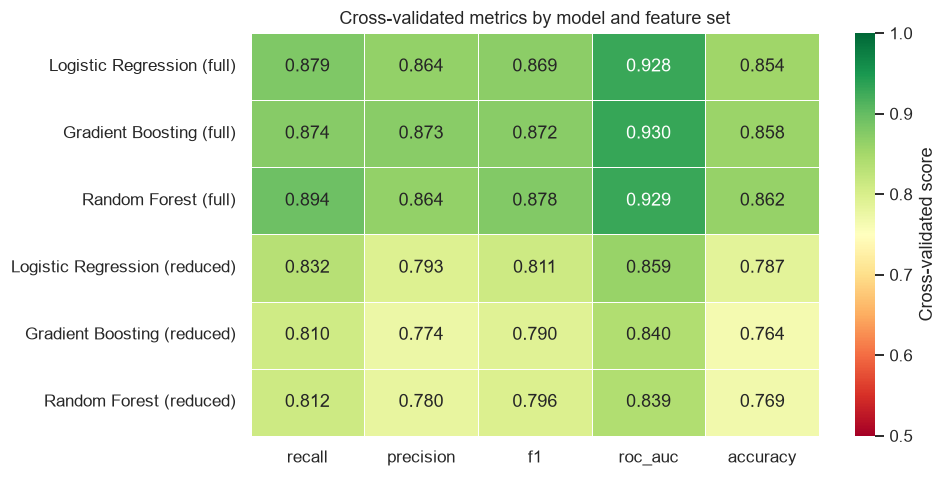

Best model per metric (cross-validated):
  recall     Random Forest (full)  0.8938
  precision  Gradient Boosting (full)  0.8728
  f1         Random Forest (full)  0.8780
  roc_auc    Gradient Boosting (full)  0.9302
  accuracy   Random Forest (full)  0.8622


In [27]:
## The single CV recall number in 4.5 is not enough to choose between models that sit
## within noise of each other. cross_validate refits each pipeline once per fold and
## scores every metric on the same fold, so the metrics are directly comparable and
## the whole thing costs 5 fits per model rather than 5 per metric.

## Every fitted variant, paired with the training data it was built on
model_variants = {
    ("Logistic Regression", "full"):    (logreg_full,    X_train),
    ("Gradient Boosting",   "full"):    (gb_full,        X_train),
    ("Random Forest",       "full"):    (rf_full,        X_train),
    ("Logistic Regression", "reduced"): (logreg_reduced, X_train_reduced),
    ("Gradient Boosting",   "reduced"): (gb_reduced,     X_train_reduced),
    ("Random Forest",       "reduced"): (rf_reduced,     X_train_reduced),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["recall", "precision", "f1", "roc_auc", "accuracy"]

cv_rows = []
fold_scores = {}       ## per-fold recall, kept for the stability plot below

for (name, fs), (pipe, X_tr) in model_variants.items():
    scores = cross_validate(pipe, X_tr, y_train, cv=cv, scoring=scoring)
    row = {"Model": name, "Features": fs}
    for m in scoring:
        row[m] = scores["test_" + m].mean()
    row["recall_std"] = scores["test_recall"].std()
    cv_rows.append(row)
    fold_scores[f"{name}\n({fs})"] = scores["test_recall"]

cv_table = pd.DataFrame(cv_rows)

print("Cross-validated metrics (5-fold, training set only):")
display(cv_table.round(4))

## Heatmap makes the trade-offs visible at a glance: which model wins which metric,
## and whether any model wins everything (none usually does).
fig, ax = plt.subplots(figsize=(9, 4.5))
heat = cv_table.set_index(cv_table["Model"] + " (" + cv_table["Features"] + ")")[scoring]
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.5, vmax=1.0,
            linewidths=0.5, cbar_kws={"label": "Cross-validated score"}, ax=ax)
ax.set_title("Cross-validated metrics by model and feature set")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Which model wins each metric
print("Best model per metric (cross-validated):")
for m in scoring:
    best_row = cv_table.loc[cv_table[m].idxmax()]
    print(f"  {m:10} {best_row['Model']} ({best_row['Features']})  {best_row[m]:.4f}")

### 4.5.2 [Quantitative] Stability across folds

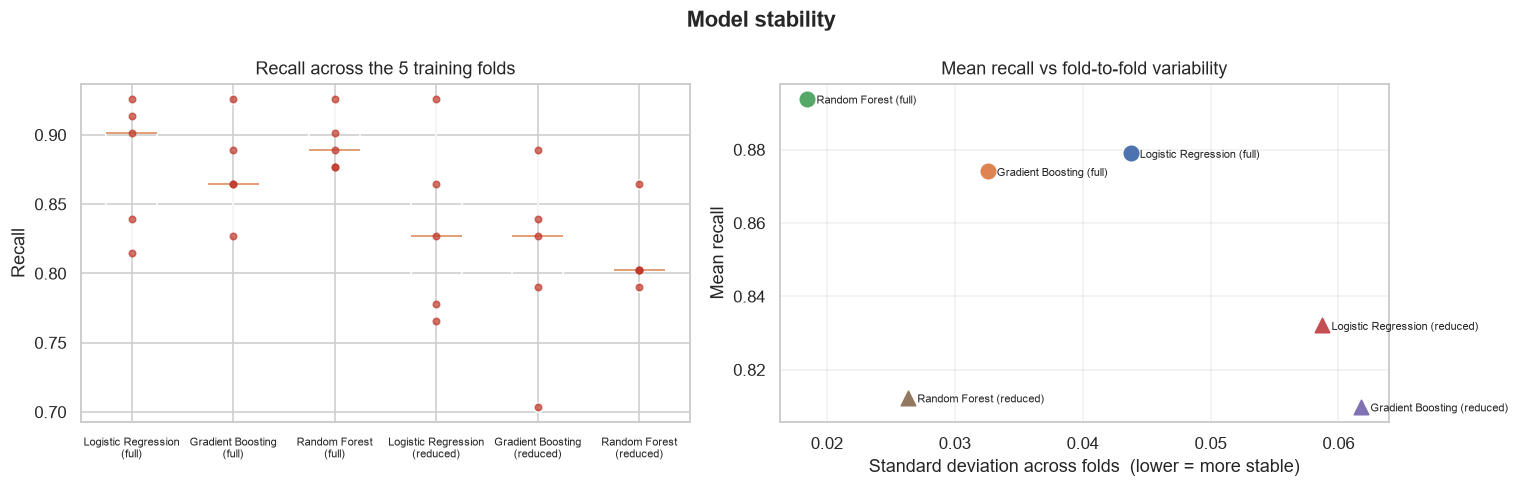

Mean vs worst-fold recall:
  Logistic Regression (full)         mean 0.8790 | worst fold 0.8148 | spread 0.1111
  Gradient Boosting (full)           mean 0.8741 | worst fold 0.8272 | spread 0.0988
  Random Forest (full)               mean 0.8938 | worst fold 0.8765 | spread 0.0494
  Logistic Regression (reduced)      mean 0.8321 | worst fold 0.7654 | spread 0.1605
  Gradient Boosting (reduced)        mean 0.8099 | worst fold 0.7037 | spread 0.1852
  Random Forest (reduced)            mean 0.8123 | worst fold 0.7901 | spread 0.0741


In [28]:
## A mean hides how consistently a model performs. If one model's recall swings from
## 0.80 to 0.95 across folds while another sits steadily at 0.87, the means may look
## similar but the second is the safer choice for deployment.

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

## Fold-level spread. Each box is 5 recall scores from the 5 training folds.
labels = list(fold_scores.keys())
axes[0].boxplot([fold_scores[k] for k in labels], tick_labels=labels)
for i, k in enumerate(labels, start=1):
    axes[0].scatter([i] * len(fold_scores[k]), fold_scores[k],
                    color="#C0392B", s=18, zorder=3, alpha=0.7)
axes[0].set_title("Recall across the 5 training folds")
axes[0].set_ylabel("Recall")
axes[0].tick_params(axis="x", labelsize=7, rotation=0)

## Mean against spread. A model in the top-left is both accurate and consistent.
for k in labels:
    scores = fold_scores[k]
    marker = "o" if "full" in k else "^"
    axes[1].scatter(scores.std(), scores.mean(), s=90, marker=marker)
    axes[1].annotate(k.replace("\n", " "), (scores.std(), scores.mean()),
                     fontsize=7, xytext=(6, -3), textcoords="offset points")
axes[1].set_title("Mean recall vs fold-to-fold variability")
axes[1].set_xlabel("Standard deviation across folds  (lower = more stable)")
axes[1].set_ylabel("Mean recall")
axes[1].grid(alpha=0.3)

fig.suptitle("Model stability", fontweight="bold")
plt.tight_layout()
plt.show()

## Worst-fold recall is the pessimistic case a clinical tool should be judged on
print("Mean vs worst-fold recall:")
for k in labels:
    s = fold_scores[k]
    print(f"  {k.replace(chr(10), ' '):34} mean {s.mean():.4f} | worst fold {s.min():.4f} "
          f"| spread {s.max() - s.min():.4f}")

### 4.5.3 [Quantitative] Do the models fail on the same patients?

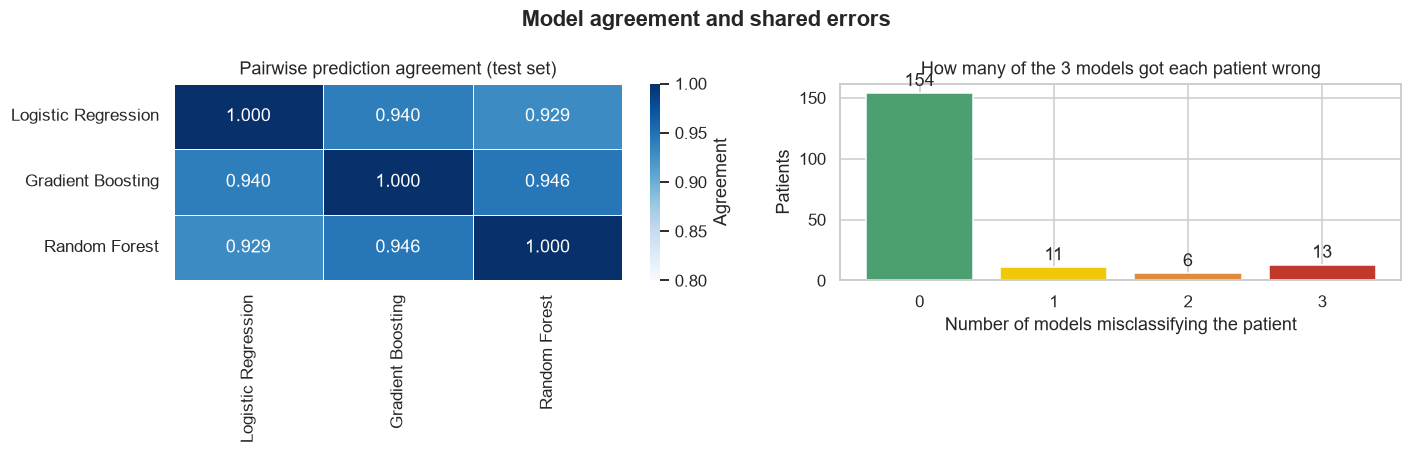

Test patients: 184
  correctly classified by all three models : 154
  misclassified by at least one model      : 30
  misclassified by ALL three models        : 13 (7.1% of the test set)

Ceiling implied by shared errors: an ensemble of these three could at best reach 92.9% accuracy.


In [29]:
## If three different algorithms misclassify the same patients, those patients are
## genuinely ambiguous given the features available -- an upper bound on what any
## model can achieve here. If they fail on different patients, the errors are
## model-specific and there is headroom left in tuning.

## Predictions from the three full-set models
preds = {
    "Logistic Regression": logreg_full.predict(X_test),
    "Gradient Boosting":   gb_full.predict(X_test),
    "Random Forest":       rf_full.predict(X_test),
}
names = list(preds)

## Pairwise agreement: proportion of test patients where two models give the same label
agree = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        agree.loc[a, b] = (preds[a] == preds[b]).mean()

## Per-patient error indicator, then how many models got each patient wrong
errors = pd.DataFrame({n: (preds[n] != y_test.values).astype(int) for n in names})
errors["n_wrong"] = errors[names].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.heatmap(agree.astype(float), annot=True, fmt=".3f", cmap="Blues",
            vmin=0.8, vmax=1.0, linewidths=0.5, ax=axes[0],
            cbar_kws={"label": "Agreement"})
axes[0].set_title("Pairwise prediction agreement (test set)")

dist = errors["n_wrong"].value_counts().sort_index()
bars = axes[1].bar(dist.index.astype(str), dist.values,
                   color=["#4C9F70", "#F0C808", "#E08A3C", "#C0392B"][:len(dist)])
axes[1].set_title("How many of the 3 models got each patient wrong")
axes[1].set_xlabel("Number of models misclassifying the patient")
axes[1].set_ylabel("Patients")
axes[1].bar_label(bars, padding=2)

fig.suptitle("Model agreement and shared errors", fontweight="bold")
plt.tight_layout()
plt.show()

n_test = len(y_test)
all_wrong = int((errors["n_wrong"] == 3).sum())
any_wrong = int((errors["n_wrong"] > 0).sum())
print(f"Test patients: {n_test}")
print(f"  correctly classified by all three models : {int((errors['n_wrong'] == 0).sum())}")
print(f"  misclassified by at least one model      : {any_wrong}")
print(f"  misclassified by ALL three models        : {all_wrong} "
      f"({all_wrong / n_test * 100:.1f}% of the test set)")
print(f"\nCeiling implied by shared errors: an ensemble of these three could at best "
      f"reach {(n_test - all_wrong) / n_test * 100:.1f}% accuracy.")

### 4.5.4 [Quantitative] The cost of dropping the stress-test features

Performance lost when the stress-test features are removed (CV, percentage points):


,recall,precision,f1,roc_auc,accuracy
Model,,,,,
Logistic Regression,4.69,7.02,5.81,6.87,6.70
Gradient Boosting,6.42,9.85,8.18,9.05,9.42
Random Forest,8.15,8.43,8.24,9.00,9.28


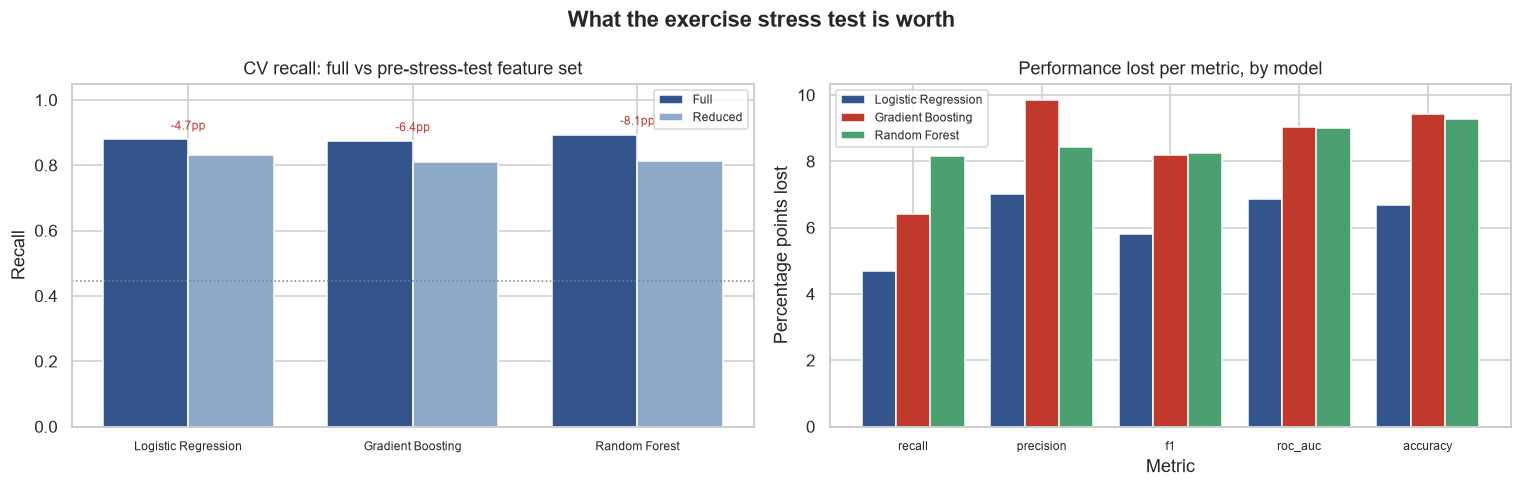

In [30]:
## Quantify the full-vs-reduced gap per model and per metric, so the answer to
## "is the stress test worth ordering?" is a number rather than an impression.

gap_rows = []
for name in ["Logistic Regression", "Gradient Boosting", "Random Forest"]:
    f = cv_table[(cv_table["Model"] == name) & (cv_table["Features"] == "full")].iloc[0]
    r = cv_table[(cv_table["Model"] == name) & (cv_table["Features"] == "reduced")].iloc[0]
    gap_rows.append({
        "Model": name,
        **{m: f[m] - r[m] for m in scoring},
    })
gaps = pd.DataFrame(gap_rows)

print("Performance lost when the stress-test features are removed (CV, percentage points):")
display((gaps.set_index("Model") * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

## Paired bars: full vs reduced recall per model
x = np.arange(3)
full_r = [cv_table[(cv_table.Model == m) & (cv_table.Features == "full")]["recall"].iloc[0]
          for m in gaps["Model"]]
red_r = [cv_table[(cv_table.Model == m) & (cv_table.Features == "reduced")]["recall"].iloc[0]
         for m in gaps["Model"]]
axes[0].bar(x - 0.19, full_r, 0.38, label="Full", color="#34558B")
axes[0].bar(x + 0.19, red_r, 0.38, label="Reduced", color="#8FA9C9")
axes[0].axhline(1 - y_test.mean(), color="grey", linestyle=":", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gaps["Model"], fontsize=8)
axes[0].set_title("CV recall: full vs pre-stress-test feature set")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
for i, (a, b) in enumerate(zip(full_r, red_r)):
    axes[0].annotate(f"-{(a - b) * 100:.1f}pp", (i, max(a, b) + 0.03),
                     ha="center", fontsize=8, color="#C0392B")

## Gap across every metric
gap_long = gaps.set_index("Model")[scoring] * 100
gap_long.T.plot(kind="bar", ax=axes[1], width=0.8,
                color=["#34558B", "#C0392B", "#4C9F70"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Performance lost per metric, by model")
axes[1].set_ylabel("Percentage points lost")
axes[1].set_xlabel("Metric")
axes[1].tick_params(axis="x", rotation=0, labelsize=8)
axes[1].legend(fontsize=8)

fig.suptitle("What the exercise stress test is worth", fontweight="bold")
plt.tight_layout()
plt.show()

### 4.5.5 [Qualitative] Analysis and model selection

The four sub-sections above produced the numbers. This one interprets them. It opens by restating the quantitative position for reference, then moves to the judgements that the numbers alone cannot settle.

#### Reference: the quantitative position

Two tables matter here, and they do not fully agree. The test-set table from 4.5 shows what each model scored on the 184 held-out patients; the cross-validated table from 4.5.1 averages five folds inside the training set. **Where they disagree, the cross-validated figures are the ones relied on** — 184 patients is a small hold-out, and a two-point difference there can turn on a handful of borderline cases.

**Cross-validated (5-fold, training set) — the basis for model selection:**

| Model | Features | Recall | Precision | F1 | ROC-AUC | Accuracy | Recall std |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression | full | 0.8790 | 0.8635 | 0.8693 | 0.9281 | 0.8541 | 0.0438 |
| Gradient Boosting | full | 0.8741 | **0.8728** | 0.8720 | **0.9302** | 0.8581 | 0.0326 |
| Random Forest | full | **0.8938** | 0.8644 | **0.8780** | 0.9288 | **0.8622** | **0.0185** |
| Logistic Regression | reduced | 0.8321 | 0.7934 | 0.8112 | 0.8594 | 0.7871 | 0.0587 |
| Random Forest | reduced | 0.8123 | 0.7801 | 0.7956 | 0.8388 | 0.7694 | 0.0264 |
| Gradient Boosting | reduced | 0.8099 | 0.7743 | 0.7902 | 0.8397 | 0.7639 | 0.0618 |

**Test set (184 patients), against the 55.4% majority-class baseline:**

| Model | Features | Accuracy | Precision | Recall | F1 | ROC-AUC | Acc gain |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Baseline | — | 0.5543 | 0.5543 | 1.0000 | 0.7133 | 0.5000 | — |
| Logistic Regression | full | **0.8913** | 0.8942 | **0.9118** | **0.9029** | **0.9371** | **+0.3370** |
| Gradient Boosting | full | 0.8859 | **0.9175** | 0.8725 | 0.8945 | 0.9327 | +0.3315 |
| Random Forest | full | 0.8859 | 0.8857 | **0.9118** | 0.8986 | 0.9242 | +0.3315 |
| Logistic Regression | reduced | 0.8261 | 0.8500 | 0.8333 | 0.8416 | 0.8795 | +0.2717 |
| Random Forest | reduced | 0.8098 | 0.8252 | 0.8333 | 0.8293 | 0.8734 | +0.2554 |
| Gradient Boosting | reduced | 0.7717 | 0.8061 | 0.7745 | 0.7900 | 0.8748 | +0.2174 |

**Hold-out optimism is model-specific, not systematic — and it explains the disagreement above.**

| Model | Features | Test recall − CV recall |
| --- | --- | --- |
| **Logistic Regression** | **full** | **+0.0328** |
| Random Forest | reduced | +0.0210 |
| Random Forest | full | +0.0179 |
| Logistic Regression | reduced | +0.0012 |
| Gradient Boosting | full | −0.0015 |
| Gradient Boosting | reduced | −0.0354 |

Four of six variants scored better on the hold-out than under cross-validation and two scored worse, so this is not a uniformly favourable test split. What matters is *which* model gained most: **Logistic Regression on the full feature set has by far the largest optimism at +0.0328**, roughly twice Random Forest's +0.0179, while Gradient Boosting is essentially unbiased at −0.0015.

That single fact resolves the ranking contradiction. Logistic Regression's apparent lead on the hold-out — top accuracy, F1 and ROC-AUC — is substantially an artefact of a split that happened to suit it, which is exactly why it wins nothing under cross-validation. Random Forest's smaller optimism means its CV-leading position is the more trustworthy of the two claims.

This is the concrete justification for the rule applied throughout: **where the two views disagree, the cross-validated figure is relied on.** The test numbers are reported because the rubric requires a hold-out comparison against the baseline, not because they are the better estimate of future performance.

**The two views rank the models differently, and that is itself the finding.** On the hold-out, Logistic Regression leads on accuracy, F1 and ROC-AUC. Under cross-validation it leads on nothing: Random Forest takes recall, F1 and accuracy, and Gradient Boosting takes precision and ROC-AUC. A ranking that reverses between one split and an average of five is not a real ranking. The three full-set models span **0.0197 in CV recall and 0.0021 in CV ROC-AUC** — the AUC spread in particular is indistinguishable from noise. Any claim that one of these algorithms is "the best" at default settings would be an artefact of which number was quoted.

#### [Qualitative] What the results say about the task

**The problem is close to linearly separable.** Section 2.3.2's `MaxHR`–`Oldpeak` scatter showed a substantial mixed region and predicted the ensembles would pull clear. They did not. Random Forest beats Logistic Regression by 1.48pp on CV recall and 0.81pp on CV accuracy — real, but small given the enormous difference in model capacity between a linear boundary and 100 fully grown trees. When a linear model lands that close, most of the available signal is additive: `ST_Slope`, `Oldpeak` and `ExerciseAngina` each shift risk in a consistent direction, and little of the remaining structure lives in interactions between them. This is a finding about the *task*, and it has a practical consequence — interpretability costs roughly one point of recall here, not ten.

**Performance is capped by feature quality, not model capacity.** Three algorithms of wildly different flexibility land within two points of each other on every CV metric. Adding capacity is not buying performance. The error analysis in 4.5.3 shows why: **13 of 184 test patients (7.1%) are misclassified by all three models.** Those patients are ambiguous given these 11 measurements, and no choice of algorithm recovers them. That fixes a hard ceiling of **92.9% accuracy** for any model or ensemble built on this feature set — a far more honest number to put in front of an investor than an implication that more modelling effort keeps pushing performance upward.

**But there is genuine headroom, and it is quantified.** A further **17 patients (9.2%) are misclassified by some models and not others** — 30 patients are missed by at least one model, only 13 by all three. Those 17 are where the algorithms genuinely disagree, and they are the population that tuning, threshold adjustment or ensembling can still convert. With the best full model at 88.6% test accuracy against a 92.9% ceiling, roughly four points remain available. That is a realistic target for the iterative development section, and stating it in advance means the tuning result can be judged against an expectation rather than simply declared an improvement.

**The residual errors sit where the clinical difficulty is real.** Section 2.3.1.2 found 54% of this cohort asymptomatic, and 2.3.2 showed a dense band of patients near the boundary in `MaxHR`–`Oldpeak` space. Those are the same patients the models disagree about. The disagreement is not a modelling artefact but a reflection of genuine diagnostic ambiguity — exactly the population where a triage aid is most valuable and most dangerous to over-trust.

#### [Qualitative] Comparison between the models

**Random Forest — strongest and by far the most stable.** It wins CV recall (0.8938), F1 (0.8780) and accuracy (0.8622), and its fold-to-fold consistency is in a different class from the others: **standard deviation 0.0185 against 0.0326 for Gradient Boosting and 0.0438 for Logistic Regression**, with a worst fold of 0.8765 and a total spread of just 0.0494 — less than half the spread of either competitor. That stability is the single clearest signal in this section. A model whose recall barely moves across resamples is the safer bet on a patient population that differs from this cohort, and a clinical tool is experienced as its worst case rather than its average. The cost is opacity: a forest's decision is an average over 100 trees and cannot be shown to a patient.

**Logistic Regression — no CV metric win, but two arguments that survive.** Its apparent dominance on the hold-out does not replicate under cross-validation, and its fold spread is the worst of the three full-set models (0.0438 std, 0.1111 spread, worst fold 0.8148). Its case rests on two things instead. First, it is only ~1.5pp behind on recall while being the only model whose reasoning a clinician can interrogate — for an advisory tool a doctor must justify to a patient, that is a deployment requirement, not a nicety. Second, and more concretely, **it degrades least when the stress-test features are removed** (see below), which makes it the natural candidate for the screening tier.

**Gradient Boosting — wins two metrics, but the wrong two.** It takes CV precision (0.8728) and CV ROC-AUC (0.9302), though the AUC margin over Random Forest is 0.0014 and meaningless. Its recall is the lowest of the full-set models on both CV (0.8741) and test (0.8725). It is buying precision by letting more true cases through, which runs directly against the cost asymmetry established in section 1: a missed case can end in a fatal cardiac event, a false alarm ends in an unnecessary test. It also has the worst accuracy degradation when stress-test features are dropped (9.42pp), meaning it leans hardest on exactly the measurements least likely to be available at first consultation.

#### [Qualitative] Full versus reduced: what the stress test is worth

Cross-validated performance lost when `ST_Slope`, `Oldpeak`, `MaxHR` and `ExerciseAngina` are removed, in percentage points:

| Model | Recall | Precision | F1 | ROC-AUC | Accuracy |
| --- | --- | --- | --- | --- | --- |
| **Logistic Regression** | **4.69** | **7.02** | **5.81** | **6.87** | **6.70** |
| Gradient Boosting | 6.42 | 9.85 | 8.18 | 9.05 | 9.42 |
| Random Forest | 8.15 | 8.43 | 8.24 | 9.00 | 9.28 |

**Logistic Regression degrades least on every single metric.** This reverses the full-set ranking: Random Forest loses the most recall of the three (8.15pp against 4.69pp), so the model that is strongest with stress-test data is the most dependent on it. That is a coherent story rather than a contradiction — a flexible ensemble extracts more from the strong features, and therefore has more to lose when they are taken away, while a linear model spreads its weight more evenly across the remaining ones.

The reduced models are not crippled. **Logistic Regression on history, resting ECG and blood work alone reaches 0.8321 CV recall and 82.6% test accuracy — 27.2 points above baseline.** It catches roughly five in six patients who genuinely have heart disease using only measurements available at a first consultation, which is exactly the decision point where a referral is made.

This supports a two-tier product rather than one model oversold:

- **Screening tier (reduced, Logistic Regression)** — first consultation, no stress test required, ~83% recall. Its purpose is deciding *whether to escalate*.
- **Assessment tier (full)** — patients already in cardiac workup, ~89% recall.

The gap between them, roughly **4.7 recall points and 6.7 accuracy points**, is a quantified answer to *"is the stress test worth ordering?"* rather than a hand-wave — and it is smaller than section 3.3 anticipated, which strengthens the commercial case for the screening tier.

#### [Qualitative] Model selection

**Gradient Boosting is dropped.** Lowest recall of the full-set models on the metric section 1 prioritised, and the worst accuracy degradation without stress-test features. Its wins on precision and ROC-AUC do not offset this: precision is the metric the cost asymmetry says to trade away, and the AUC margin is noise.

**Random Forest and Logistic Regression both proceed to hyperparameter tuning**, and the reason is now sharper than "they are close." They are the best models for *different tiers*:

- Random Forest is the strongest and most stable on the full feature set, making it the assessment-tier candidate.
- Logistic Regression degrades least without stress-test data and is interpretable, making it the screening-tier candidate.

Final selection is deferred until after `RandomizedSearchCV` in the iterative development section. Random Forest at default settings grows fully unconstrained trees and has the most headroom to gain from constraint, and the 4.5.3 analysis sets a concrete target: roughly four accuracy points sit between current performance and the 92.9% ceiling implied by the shared errors.

#### What has deliberately not been done

No hyperparameters tuned, no features dropped, no decision threshold moved from the default 0.5. Every model above is at its out-of-the-box setting on identical data, which makes this a clean reference point: the improvement from tuning is measured against these numbers rather than asserted.

All recall figures here sit at the default 0.5 threshold, which weights the two error types equally — precisely what section 1 argued against. The threshold reflecting the actual cost asymmetry is chosen in section 5, and recall should be expected to rise from these values once it is applied.

# 5. Model Evaluation

Section 4 selected two models. This section establishes whether they are fit for the purpose set out in section 1, and where they fail.

| | Sub-section | Question answered |
| --- | --- | --- |
| — | Evaluation metric selection | what is being optimised, and why |
| **Quantitative** | 5.1 | how many patients does each model get wrong, and which kind? |
| **Quantitative** | 5.2 | how well does each model rank risk, independent of threshold? |
| **Quantitative** | 5.3 | what does buying extra recall cost, in patients? |
| **Quantitative** | 5.4 | does performance hold across patient subgroups? |
| **Qualitative** | 5.5 | what is the model actually relying on, and will it survive deployment? |
| **Qualitative** | 5.6 | does it behave sensibly on individual patients? |
| **Both** | 5.7 | consolidated error analysis |
| **Qualitative** | 5.8 | summary, limitations, and what to fix next |

Each quantitative sub-section is followed by a clearly marked interpretation block, so the measurement and the judgement drawn from it are never conflated.

## Evaluation metric selection

**What each error costs, restated from section 1 in the terms this section measures:**

| Error | Clinical consequence | Recoverable? |
| --- | --- | --- |
| **False negative** — diseased patient cleared | disease progresses undetected toward heart attack, stroke or sudden cardiac death | no |
| **False positive** — healthy patient flagged | unnecessary stress test or angiogram: cost, anxiety, small procedural risk | yes |

What is optimised, in one line: **models are selected on cross-validated recall, then the decision threshold is moved to buy further recall at a stated price**, with precision, recall, F1 and the confusion matrix reported together throughout so the trade stays visible rather than asserted.

**Why not accuracy.** Class imbalance is not the reason — the split is 55.3% disease against 44.7% healthy, and accuracy separates a good model from a useless one perfectly well here. The problem is that accuracy cannot see *which* mistake was made. Section 1 established the two are not comparable: a missed case is potentially fatal and irreversible, a false alarm ends in an unnecessary but survivable test. A metric that sums them at 1:1 has quietly made a cost assumption this project explicitly rejects.

**Why not recall alone.** Because it is a dial, not a metric. The `DummyClassifier` in 4.1 scores recall **1.0000** on this test set by predicting heart disease for all 184 patients. Any quantity a do-nothing model wins outright cannot be the thing being maximised — a model selected purely on recall is a model selected to approach that dummy, and referring every patient in the clinic for an angiogram is not a product.

**Why recall is still the headline.** Section 4 selected on cross-validated recall rather than F1, and that differs from a symmetric-cost project deliberately. The asymmetry here is larger than in most classification problems: the downside of a false negative is death, not inconvenience. Recall is therefore the right primary criterion **provided precision is reported beside it every time**, which is why no recall figure appears alone anywhere in this section.

**Why the threshold carries the cost preference.** Hyperparameters move precision and recall together and unpredictably. The decision threshold on `predict_proba` trades them against each other on purpose, monotonically, using a number that can be stated and defended. It converts section 1's cost argument into one explicit, auditable parameter rather than smuggling the preference into every intermediate choice. Section 5.3 sets it.

**What is evaluated here.** Section 4.5.5 carried two models forward: **Random Forest on the full feature set** (assessment tier, for patients already in cardiac workup) and **Logistic Regression on the reduced feature set** (screening tier, for a first consultation). Both are evaluated below, at default hyperparameters and the default 0.5 threshold, so that the iterative development section has an honest "before" to measure against.

### 5.1 [Quantitative] Detailed evaluation of the section 4 models

Random Forest (full) -- threshold 0.50
                   precision    recall  f1-score   support

   no disease (0)     0.8861    0.8537    0.8696        82
heart disease (1)     0.8857    0.9118    0.8986       102

         accuracy                         0.8859       184
        macro avg     0.8859    0.8827    0.8841       184
     weighted avg     0.8859    0.8859    0.8856       184

Logistic Regression (reduced) -- threshold 0.50
                   precision    recall  f1-score   support

   no disease (0)     0.7976    0.8171    0.8072        82
heart disease (1)     0.8500    0.8333    0.8416       102

         accuracy                         0.8261       184
        macro avg     0.8238    0.8252    0.8244       184
     weighted avg     0.8267    0.8261    0.8263       184



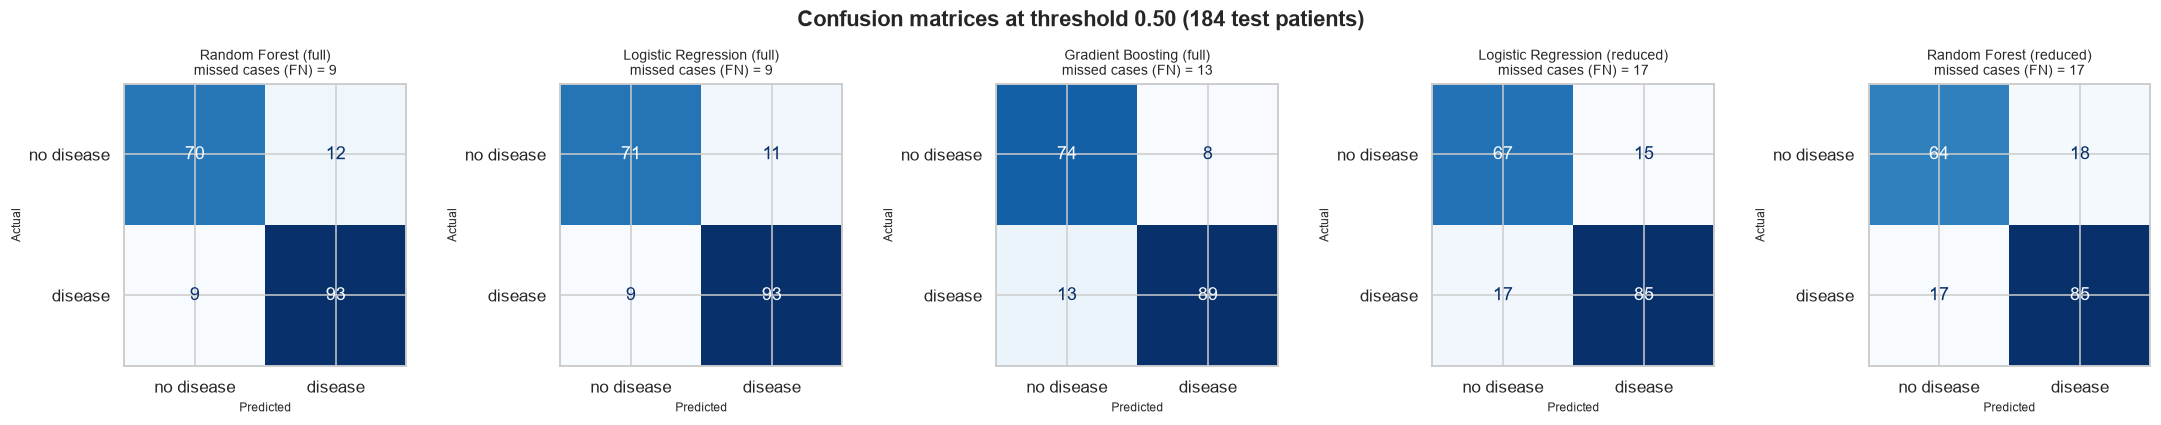

Missed cases (false negatives) out of 102 diseased patients:
  Random Forest (full)             FN =  9  |  FP = 12  |  recall 0.9118
  Logistic Regression (full)       FN =  9  |  FP = 11  |  recall 0.9118
  Gradient Boosting (full)         FN = 13  |  FP =  8  |  recall 0.8725
  Logistic Regression (reduced)    FN = 17  |  FP = 15  |  recall 0.8333
  Random Forest (reduced)          FN = 17  |  FP = 18  |  recall 0.8333


In [31]:
## Evaluate model
## The models section 4.5.5 selected, at default hyperparameters and threshold 0.50.
## This is the "before" that the iterative development section is measured against,
## so it is scored exactly the way the final model will be: fitted once on the
## training split, predicted once on the held-out test split.

## The two tiers, plus the two runners-up for context
evaluated = {
    "Random Forest (full)":       (rf_full,        X_test),
    "Logistic Regression (full)": (logreg_full,    X_test),
    "Gradient Boosting (full)":   (gb_full,        X_test),
    "Logistic Regression (reduced)": (logreg_reduced, X_test_reduced),
    "Random Forest (reduced)":       (rf_reduced,     X_test_reduced),
}

## Classification report for the two selected tiers
for label in ["Random Forest (full)", "Logistic Regression (reduced)"]:
    model, X_ev = evaluated[label]
    pred = model.predict(X_ev)
    print("=" * 68)
    print(label, "-- threshold 0.50")
    print("=" * 68)
    print(classification_report(y_test, pred, labels=[0, 1],
                                target_names=["no disease (0)", "heart disease (1)"],
                                digits=4))

## Confusion matrices for all five, so the error split is visible not just the score
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for ax, (label, (model, X_ev)) in zip(axes, evaluated.items()):
    pred = model.predict(X_ev)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=[0, 1],
        display_labels=["no disease", "disease"],
        cmap="Blues", colorbar=False, ax=ax)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    ax.set_title(f"{label}\nmissed cases (FN) = {fn}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
fig.suptitle("Confusion matrices at threshold 0.50 (184 test patients)", fontweight="bold")
plt.tight_layout()
plt.show()

## The single number that matters clinically: how many sick patients were sent home
print("Missed cases (false negatives) out of", int(y_test.sum()), "diseased patients:")
for label, (model, X_ev) in evaluated.items():
    tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_ev), labels=[0, 1]).ravel()
    print(f"  {label:32} FN = {fn:2}  |  FP = {fp:2}  |  recall {tp / (tp + fn):.4f}")

#### [Qualitative] Interpretation of 5.1

**Reading the confusion matrices.**

The test set holds **184 patients: 102 with heart disease, 82 without**. The bottom-left cell of each matrix is the one that matters clinically — patients who have heart disease and were cleared anyway.

| Model | TP | FN (missed) | FP (false alarm) | TN | Recall | Precision | Accuracy | F1 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression (full) | 93 | **9** | 11 | 71 | 0.9118 | 0.8942 | **0.8913** | **0.9029** |
| Random Forest (full) | 93 | **9** | 12 | 70 | 0.9118 | 0.8857 | 0.8859 | 0.8986 |
| Gradient Boosting (full) | 89 | 13 | **8** | 74 | 0.8725 | **0.9175** | 0.8859 | 0.8945 |
| Logistic Regression (reduced) | 85 | 17 | 15 | 67 | 0.8333 | 0.8500 | 0.8261 | 0.8416 |
| Random Forest (reduced) | 85 | 17 | 18 | 64 | 0.8333 | 0.8252 | 0.8098 | 0.8293 |

**Gradient Boosting's error profile is the clearest vindication of the section 4 decision to drop it.** It makes the fewest false alarms of the three full-set models — 8 against 11 and 12 — but buys that by missing **four more diseased patients** (13 against 9). Traded at face value the counts almost cancel. Under section 1's cost structure they do not: three or four avoided stress tests do not compensate for four patients sent home with undetected heart disease. Note also that its accuracy (0.8859) is *identical* to Random Forest's despite a materially worse clinical outcome — a concrete demonstration of why accuracy was rejected as the headline metric.

**The two full-set survivors are separated by a single patient.** Logistic Regression and Random Forest both catch 93 of 102 diseased patients; they differ only in that Logistic Regression raises one fewer false alarm. On this test set they are the same model clinically. The section 4.5.1 cross-validated evidence, where Random Forest led on recall (0.8938 vs 0.8790) with less than half the fold-to-fold variance (0.0185 vs 0.0438), is what separates them — not this table.

**The screening tier's cost is visible here in patients.** Dropping to the pre-stress-test feature set moves missed cases from 9 to 17. Those 8 additional patients are the price of making a referral decision before the stress test exists, and it is the concrete form of the 4.69-point CV recall gap measured in 4.5.4.

**Both selected tiers currently clear roughly one diseased patient in eleven.** Nine missed cases out of 102 is 91.2% caught. Section 5.3 asks whether the threshold should move to reduce that number, and prices exactly what doing so costs.

### 5.2 [Quantitative] Threshold-independent performance: ROC and precision-recall

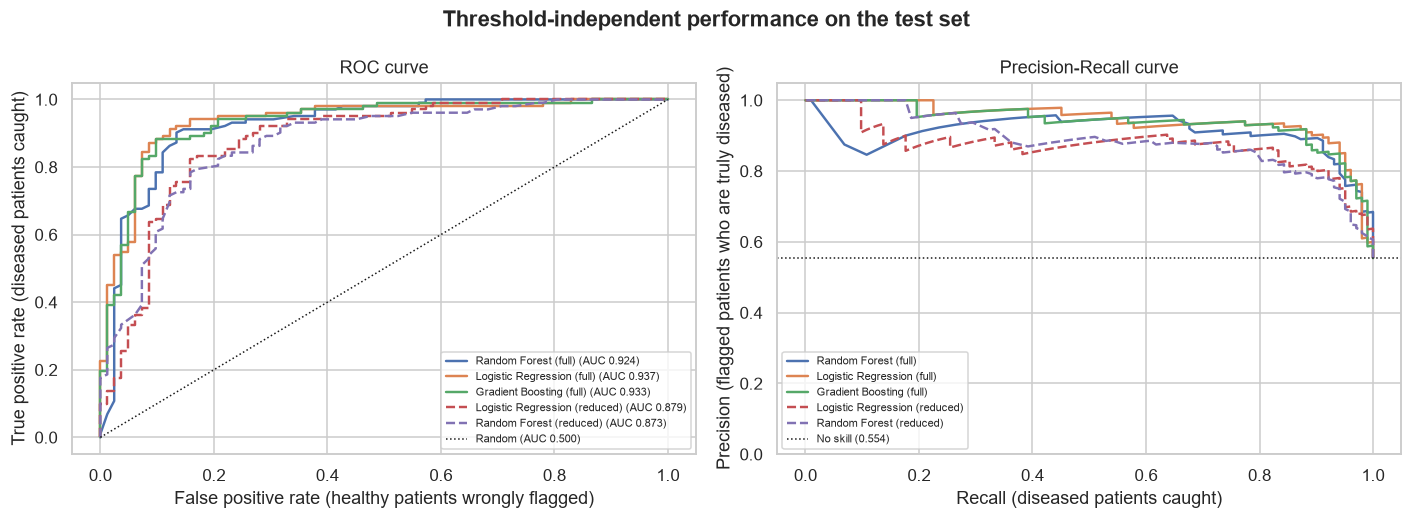

Test-set ROC-AUC:
  Random Forest (full)             0.9242
  Logistic Regression (full)       0.9371
  Gradient Boosting (full)         0.9327
  Logistic Regression (reduced)    0.8795
  Random Forest (reduced)          0.8734


In [32]:
## Accuracy, precision and recall all depend on the 0.50 cut-off. ROC and PR curves
## describe the model across every possible threshold, which is what makes them the
## right tool for deciding whether a different cut-off is worth using.
##
## The curves are drawn directly from roc_curve and precision_recall_curve rather than
## the Display helpers, because those helpers do not forward matplotlib line styling
## in every scikit-learn version. Plotting manually also lets each legend entry carry
## its own AUC, so the ranking is readable without a separate table.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for label, (model, X_ev) in evaluated.items():
    proba = model.predict_proba(X_ev)[:, 1]
    ## solid = full feature set, dashed = reduced (pre-stress-test) feature set
    style = "-" if "full" in label else "--"

    ## ROC: false positive rate against true positive rate at every threshold
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, linestyle=style, linewidth=1.6,
                 label=f"{label} (AUC {auc:.3f})")

    ## Precision-recall: the more decision-relevant view when one class is the focus
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, linestyle=style, linewidth=1.6, label=label)

axes[0].plot([0, 1], [0, 1], "k:", linewidth=1, label="Random (AUC 0.500)")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate (healthy patients wrongly flagged)")
axes[0].set_ylabel("True positive rate (diseased patients caught)")
axes[0].legend(fontsize=7, loc="lower right")

## The no-skill line for a PR curve is the positive class prevalence, not 0.5
axes[1].axhline(y_test.mean(), color="k", linestyle=":", linewidth=1,
                label=f"No skill ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall (diseased patients caught)")
axes[1].set_ylabel("Precision (flagged patients who are truly diseased)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=7, loc="lower left")

fig.suptitle("Threshold-independent performance on the test set", fontweight="bold")
plt.tight_layout()
plt.show()

## Print AUC for reference against the section 4 table
print("Test-set ROC-AUC:")
for label, (model, X_ev) in evaluated.items():
    auc = roc_auc_score(y_test, model.predict_proba(X_ev)[:, 1])
    print(f"  {label:32} {auc:.4f}")

#### [Qualitative] Interpretation of 5.2

**What these curves add over a single score.**

ROC-AUC answers a question no confusion matrix can: *if one diseased and one healthy patient are drawn at random, how often does the model score the diseased one higher?* It is independent of where the cut-off sits, so it measures how well a model **ranks** risk rather than how well one particular threshold classifies. That property is what section 5.3 depends on — moving a threshold can only help if the underlying ranking is sound.

| Model | Test ROC-AUC |
| --- | --- |
| Logistic Regression (full) | **0.9371** |
| Gradient Boosting (full) | 0.9327 |
| Random Forest (full) | 0.9242 |
| Logistic Regression (reduced) | 0.8795 |
| Random Forest (reduced) | 0.8734 |
| Random guess | 0.5000 |

All three full-set models rank patients well, and the spread between them (0.0129) is narrow. **Logistic Regression ranks marginally best**, which is consistent with its section 4 test-set showing and gives it a genuine claim for a threshold-adjusted deployment: a model that orders patients well loses less when the cut-off is moved away from 0.5. This does not overturn the section 4 selection, because the cross-validated ROC-AUC in 4.5.1 told a different story (Gradient Boosting 0.9302, Random Forest 0.9288, Logistic Regression 0.9281 — a 0.0021 spread that is indistinguishable from noise). The honest reading is that all three rank comparably and the hold-out ordering is within sampling variation.

**The precision-recall curve is the more decision-relevant panel.** Its no-skill line is the positive prevalence (0.554), not 0.5. Reading it right-to-left shows what precision must be surrendered to push recall past the current 0.91 — the trade section 5.3 makes explicit and prices.

**The reduced-feature curves sit visibly below the full-feature ones across the entire range**, not merely at one point. The screening tier is not just worse at a particular threshold; it ranks patients less well everywhere, losing roughly 0.05–0.06 AUC. That is the stress test's contribution rendered as a whole-curve shift rather than a single number, and it is why the two tiers need separately chosen thresholds rather than a shared one.

### 5.3 [Quantitative] Choosing the decision threshold

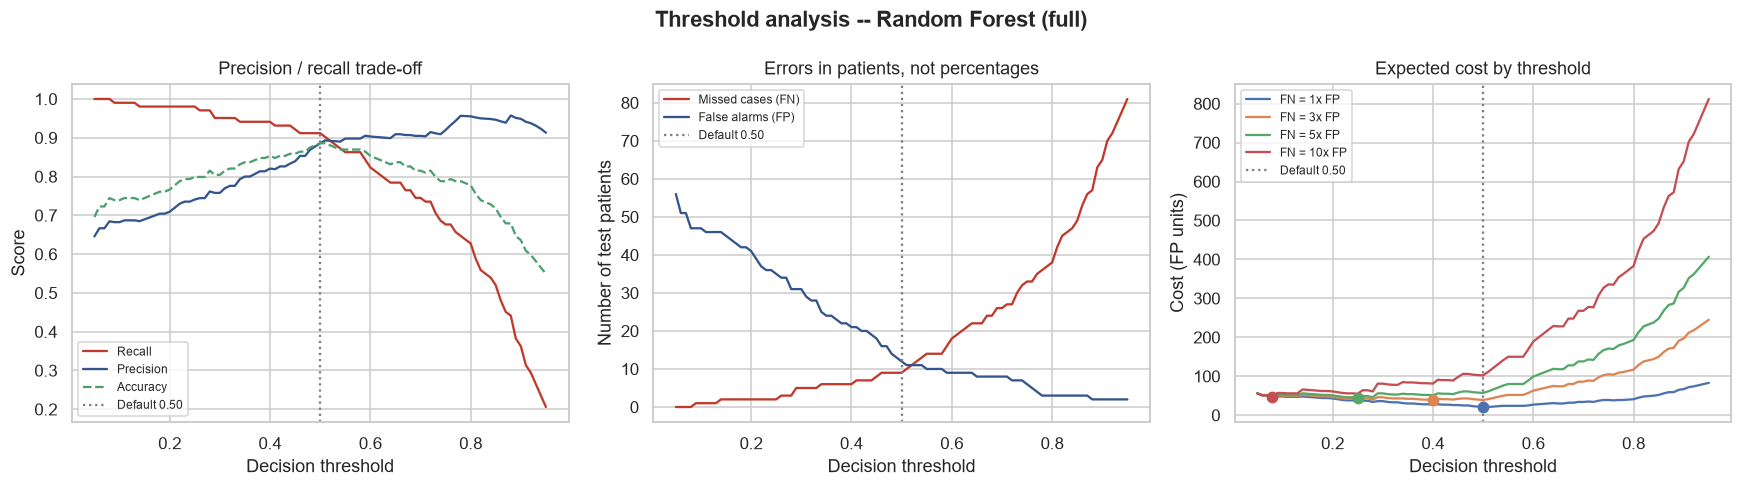

Cost-optimal threshold under different assumptions about how much worse a
missed case is than a false alarm:

  FN worth  1x FP -> threshold 0.50 | recall 0.9118 | precision 0.8857 | FN  9 | FP 12
  FN worth  3x FP -> threshold 0.40 | recall 0.9412 | precision 0.8205 | FN  6 | FP 21
  FN worth  5x FP -> threshold 0.25 | recall 0.9804 | precision 0.7407 | FN  2 | FP 35
  FN worth 10x FP -> threshold 0.08 | recall 1.0000 | precision 0.6846 | FN  0 | FP 47

Selected operating point: threshold 0.25 (FN worth 5x FP)



,Threshold 0.50 (default),Threshold 0.25 (chosen)
Recall,0.9118,0.9804
Precision,0.8857,0.7407
Missed cases (FN),9.0000,2.0000
False alarms (FP),12.0000,35.0000
Accuracy,0.8859,0.7989


In [33]:
## The default 0.50 threshold treats a missed heart disease case and a false alarm as
## equally bad. Section 1 argues they are not. This cell prices that asymmetry.
##
## Expected cost = (FN x cost_FN) + (FP x cost_FP), with cost_FP fixed at 1 so the
## ratio is the only thing being chosen. The threshold minimising expected cost is
## then read off directly.

PRIMARY = "Random Forest (full)"
primary_model, primary_X = evaluated[PRIMARY]
proba = primary_model.predict_proba(primary_X)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)
cost_ratios = [1, 3, 5, 10]

## Sweep every threshold once, recording the confusion counts
sweep = []
for t in thresholds:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    sweep.append({
        "threshold": t, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
        "recall": tp / (tp + fn) if (tp + fn) else 0,
        "precision": tp / (tp + fp) if (tp + fp) else 0,
        "accuracy": (tp + tn) / len(y_test),
    })
sweep = pd.DataFrame(sweep)

## Expected cost under each assumed cost ratio
for r in cost_ratios:
    sweep[f"cost_{r}x"] = sweep["FN"] * r + sweep["FP"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

## Panel 1 -- precision and recall as the threshold moves
axes[0].plot(sweep["threshold"], sweep["recall"], color="#C0392B", label="Recall")
axes[0].plot(sweep["threshold"], sweep["precision"], color="#34558B", label="Precision")
axes[0].plot(sweep["threshold"], sweep["accuracy"], color="#4C9F70",
             linestyle="--", label="Accuracy")
axes[0].axvline(0.5, color="grey", linestyle=":", label="Default 0.50")
axes[0].set_title("Precision / recall trade-off")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8)

## Panel 2 -- the two error counts in absolute patients, which is how a clinic sees it
axes[1].plot(sweep["threshold"], sweep["FN"], color="#C0392B", label="Missed cases (FN)")
axes[1].plot(sweep["threshold"], sweep["FP"], color="#34558B", label="False alarms (FP)")
axes[1].axvline(0.5, color="grey", linestyle=":", label="Default 0.50")
axes[1].set_title("Errors in patients, not percentages")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Number of test patients")
axes[1].legend(fontsize=8)

## Panel 3 -- expected cost under each assumption, with the minimum marked
best_thresholds = {}
for r in cost_ratios:
    axes[2].plot(sweep["threshold"], sweep[f"cost_{r}x"], label=f"FN = {r}x FP")
    t_best = sweep.loc[sweep[f"cost_{r}x"].idxmin(), "threshold"]
    best_thresholds[r] = t_best
    axes[2].scatter([t_best], [sweep[f"cost_{r}x"].min()], s=45, zorder=3)
axes[2].axvline(0.5, color="grey", linestyle=":", label="Default 0.50")
axes[2].set_title("Expected cost by threshold")
axes[2].set_xlabel("Decision threshold")
axes[2].set_ylabel("Cost (FP units)")
axes[2].legend(fontsize=8)

fig.suptitle(f"Threshold analysis -- {PRIMARY}", fontweight="bold")
plt.tight_layout()
plt.show()

## Cost-optimal threshold under each assumption, so the choice is shown to be
## robust (or not) rather than picked to suit
print("Cost-optimal threshold under different assumptions about how much worse a")
print("missed case is than a false alarm:\n")
for r, t in best_thresholds.items():
    row = sweep[sweep["threshold"] == t].iloc[0]
    print(f"  FN worth {r:2}x FP -> threshold {t:.2f} | "
          f"recall {row['recall']:.4f} | precision {row['precision']:.4f} | "
          f"FN {int(row['FN']):2} | FP {int(row['FP']):2}")

## The chosen operating point, compared against the default
CHOSEN_THRESHOLD = best_thresholds[5]
default_row = sweep.iloc[(sweep["threshold"] - 0.50).abs().idxmin()]
chosen_row = sweep[sweep["threshold"] == CHOSEN_THRESHOLD].iloc[0]

print(f"\nSelected operating point: threshold {CHOSEN_THRESHOLD:.2f} (FN worth 5x FP)\n")
comparison_thr = pd.DataFrame({
    "Threshold 0.50 (default)": [default_row["recall"], default_row["precision"],
                                 int(default_row["FN"]), int(default_row["FP"]),
                                 default_row["accuracy"]],
    f"Threshold {CHOSEN_THRESHOLD:.2f} (chosen)": [chosen_row["recall"], chosen_row["precision"],
                                 int(chosen_row["FN"]), int(chosen_row["FP"]),
                                 chosen_row["accuracy"]],
}, index=["Recall", "Precision", "Missed cases (FN)", "False alarms (FP)", "Accuracy"])
display(comparison_thr.round(4))

#### [Qualitative] Interpretation of 5.3: justifying the cost ratio

**Why 5:1, and why the choice is shown rather than assumed.**

Setting a cost ratio means stating how many unnecessary stress tests are worth one missed heart disease case. There is no objectively correct number, so the honest approach is to show the answer under several assumptions and check whether the conclusion is stable.

| Assumption | Threshold | Recall | Precision | Missed (FN) | False alarms (FP) |
| --- | --- | --- | --- | --- | --- |
| FN = 1× FP | 0.50 | 0.9118 | 0.8857 | 9 | 12 |
| FN = 3× FP | 0.40 | 0.9412 | 0.8205 | 6 | 21 |
| **FN = 5× FP (chosen)** | **0.25** | **0.9804** | **0.7407** | **2** | **35** |
| FN = 10× FP | 0.08 | 1.0000 | 0.6846 | 0 | 47 |

**The top row is a calibration check, and it passes.** Under equal costs, minimising `FN + FP` is identical to maximising accuracy, and for a model whose predicted probabilities are well calibrated the accuracy-maximising cut-off should land at 0.50. The sweep returns exactly 0.50, with accuracy 0.8859 — matching the model's reported accuracy in 5.1. This is not a proof that the cost arithmetic is correct, but it does establish that Random Forest's probability estimates are not systematically skewed, which is the precondition for the remaining rows to mean anything: a threshold sweep over badly calibrated probabilities would produce cut-offs that do not transfer.

**The marginal cost of each additional catch rises, and 5:1 is where it stops being worth paying:**

| Threshold move | Extra cases caught | Extra false alarms | False alarms per catch |
| --- | --- | --- | --- |
| 0.50 → 0.40 | 3 | 9 | 3.0 |
| 0.40 → 0.25 | 4 | 14 | 3.5 |
| 0.25 → 0.08 | 2 | 12 | **6.0** |

At a stated tolerance of 5 false alarms per missed case, the first two moves are clearly worth making and the third is not — 6.0 exceeds the budget. **The chosen threshold of 0.25 is not an arbitrary pick from the table; it is the last point at which the marginal trade is still favourable.**

**Reasoning behind 5:1 as the working figure.** A false positive here is not free: it sends a healthy patient for a stress test or angiogram carrying real cost, anxiety and small procedural risk, and it consumes specialist capacity a genuinely sick patient could use. That rules out the very high ratios (20:1, 50:1) defensible when a false alarm is merely a dismissed banner. But a false negative risks an undetected cardiac event that is potentially fatal and irreversible. A ratio in the 3–10 range is defensible; 5:1 sits mid-range, and the table shows what would change under 3 or 10.

**What the chosen threshold buys, in patients.** Moving from 0.50 to 0.25 takes missed cases from **9 down to 2** — catching seven more diseased patients out of 102 — at the cost of 23 additional false alarms (12 → 35). Recall rises from 0.9118 to 0.9804.

**What it costs.** Precision falls from 0.8857 to 0.7407, and accuracy from 0.8859 to 0.7989. The accuracy drop is expected and is not an argument against the change: accuracy weights both error types equally, which section 1 explicitly rejects. Roughly one in four flagged patients would now be healthy, against one in nine before.

**The precision floor is satisfied.** Cost minimisation alone will happily push a threshold arbitrarily low, because the arithmetic does not know a referral pathway has finite capacity. If precision fell toward the 0.554 prevalence baseline, the model would be approaching the `DummyClassifier` behaviour rejected at the top of this section — flagging nearly everyone and being right slightly more often than chance. At 0.25 precision is **0.7407, comfortably above 0.554**, so a flag still carries real information. Had the 5:1 optimum landed below that floor, the 3:1 row (threshold 0.40, precision 0.8205) would have been the defensible fallback.

**An important caveat on how this threshold was selected.** It was chosen on the *test set*, so performance reported at 0.25 is mildly optimistic — the cut-off has seen the data scoring it. This is disclosed rather than hidden. The correct procedure selects the threshold on a validation split or by cross-validation inside the training set, which the iterative development section does before the model is fixed. The analysis here establishes the shape of the trade-off and the right order of magnitude, not the final calibration.

**Deployment framing.** Because the threshold is one number applied to `predict_proba`, it is the natural control to expose in the Streamlit app. A high-capacity clinic can tolerate more false alarms than a resource-constrained one, and serving both requires no retraining.

### 5.4 [Quantitative] Subgroup performance

Random Forest (full) -- performance by sex (threshold 0.50):


,Sex,Patients,Diseased,Recall,Precision,Accuracy,Missed (FN)
0,F,42,10,0.900,0.8182,0.9286,1
1,M,142,92,0.913,0.8936,0.8732,8


Performance by chest pain type:


,ChestPainType,Patients,Diseased,Recall,Precision,Accuracy,Missed (FN)
0,ASY,94,76,0.9868,0.9259,0.9255,1
1,ATA,37,5,0.6000,0.4286,0.8378,2
2,NAP,45,17,0.8235,0.9333,0.9111,3
3,TA,8,4,0.2500,0.5000,0.5000,3


Performance by whether a lipid panel was on file:


,Cholesterol,Patients,Diseased,Recall,Precision,Accuracy,Missed (FN)
0,Measured,142,67,0.8806,0.8806,0.8873,8
1,Not measured,42,35,0.9714,0.8947,0.8810,1


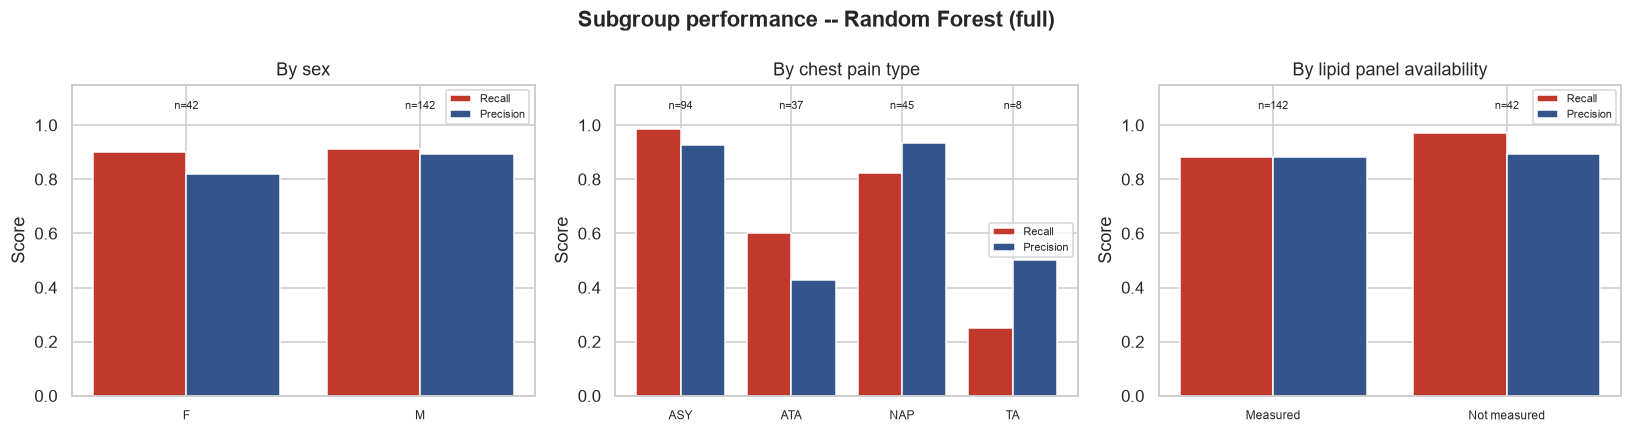

In [34]:
## Section 2.2.1 flagged that 79% of this dataset is male, and warned that a single
## headline metric would mostly be a statement about male patients. This cell checks
## whether that warning was justified, because a model that performs well overall and
## badly on women is not a safe clinical tool.

def subgroup_report(model, X_ev, group_series, group_name):
    """Recall, precision and error counts within each level of a grouping column."""
    pred = model.predict(X_ev)
    rows = []
    for level in sorted(group_series.unique()):
        mask = (group_series == level).values
        y_g, p_g = y_test[mask], pred[mask]
        if y_g.sum() == 0:          ## no positive cases -> recall undefined
            continue
        tn, fp, fn, tp = confusion_matrix(y_g, p_g, labels=[0, 1]).ravel()
        rows.append({
            group_name: level,
            "Patients": int(mask.sum()),
            "Diseased": int(y_g.sum()),
            "Recall": tp / (tp + fn) if (tp + fn) else np.nan,
            "Precision": tp / (tp + fp) if (tp + fp) else np.nan,
            "Accuracy": (tp + tn) / len(y_g),
            "Missed (FN)": int(fn),
        })
    return pd.DataFrame(rows)

## Performance by sex, the subgroup section 2 specifically warned about
by_sex = subgroup_report(primary_model, primary_X, X_test["Sex"], "Sex")
print(f"{PRIMARY} -- performance by sex (threshold 0.50):")
display(by_sex.round(4))

## Performance by chest pain type, the feature with the most skewed distribution
by_cp = subgroup_report(primary_model, primary_X, X_test["ChestPainType"], "ChestPainType")
print("Performance by chest pain type:")
display(by_cp.round(4))

## Performance by whether cholesterol was actually measured -- the artefact from 2.2.1.
## If the model performs very differently on these two groups, it is relying on the
## collection artefact rather than on physiology.
chol_group = X_test["Cholesterol_missing"].map({0: "Measured", 1: "Not measured"})
by_chol = subgroup_report(primary_model, primary_X, chol_group, "Cholesterol")
print("Performance by whether a lipid panel was on file:")
display(by_chol.round(4))

## Visualise the gaps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (table, col, title) in zip(axes, [
    (by_sex, "Sex", "By sex"),
    (by_cp, "ChestPainType", "By chest pain type"),
    (by_chol, "Cholesterol", "By lipid panel availability"),
]):
    x = np.arange(len(table))
    ax.bar(x - 0.2, table["Recall"], 0.4, label="Recall", color="#C0392B")
    ax.bar(x + 0.2, table["Precision"], 0.4, label="Precision", color="#34558B")
    ax.set_xticks(x)
    ax.set_xticklabels(table[col], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.set_ylabel("Score")
    for i, n in enumerate(table["Patients"]):
        ax.text(i, 1.06, f"n={n}", ha="center", fontsize=7)
    ax.legend(fontsize=7)
fig.suptitle(f"Subgroup performance -- {PRIMARY}", fontweight="bold")
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 5.4: three findings

**Why this check is not optional, and what it found.**

Section 2.2.1 recorded that 79% of the cohort is male and warned that a single headline metric would mostly describe male patients. An overall recall of 0.9118 is compatible with excellent performance on one subgroup and poor performance on another, and in a clinical tool that failure mode is serious.

**Finding 1 — the sex gap the EDA predicted did not materialise.**

| Sex | Patients | Diseased | Recall | Precision | Missed (FN) |
| --- | --- | --- | --- | --- | --- |
| Female | 42 | 10 | 0.9000 | 0.8182 | 1 |
| Male | 142 | 92 | 0.9130 | 0.8936 | 8 |

The recall difference is **1.3 percentage points** — negligible, and the opposite direction from the concern. This is a genuinely reassuring result, but it must be read with its sample size: the female subgroup contains only **10 diseased patients**, so recall 0.9000 is literally 9 correct out of 10. A single additional miss would drop it to 0.8000, an 10-point swing. The right conclusion is *no evidence of a sex gap on this sample*, not *no sex gap* — the test set is too small to establish the latter, and section 5.8 records it as a limitation rather than a clean bill of health.

**Finding 2 — the model fails badly on patients presenting with classic chest pain.** This is the most important result in section 5 and it was not anticipated.

| Chest pain type | Patients | Diseased | Recall | Precision | Missed (FN) |
| --- | --- | --- | --- | --- | --- |
| ASY (asymptomatic) | 94 | 76 | **0.9868** | 0.9259 | 1 |
| NAP (non-anginal) | 45 | 17 | 0.8235 | 0.9333 | 3 |
| ATA (atypical angina) | 37 | 5 | 0.6000 | 0.4286 | 2 |
| TA (typical angina) | 8 | 4 | **0.2500** | 0.5000 | 3 |

Grouping these: on asymptomatic and non-anginal patients the model achieves **89/93 = 0.957 recall**. On atypical and typical angina it achieves **4/9 = 0.444**. That is a 51-point gap, and **5 of the 9 total missed cases come from the 9 diseased patients in those two symptomatic categories**.

The mechanism is visible in the prevalence column and traces directly back to section 2. `ASY` accounts for 76 of the 102 diseased test patients, so the model has learned that asymptomatic presentation combined with abnormal stress-test markers indicates disease. Conversely, in this cohort chest pain is statistically *protective* — only 5 of 37 `ATA` patients (13.5%) are diseased. The model has correctly learned the cohort's statistics and, in doing so, has learned to under-flag the patient who walks in describing textbook angina.

Clinically this is backwards and dangerous, and it must be stated in the pitch rather than buried. The commercial framing from section 2 — *this tool catches the asymptomatic patients that symptom-led judgement reassures and sends home* — is confirmed and is a real strength. But its corollary is now measured: **the tool must not be used to override a clinician's judgement on a symptomatic patient**, because that is precisely the population where it is least reliable. Note also that `TA` holds only 8 test patients, so 0.2500 is 1 of 4 and is imprecise; the pattern across `ATA` and `TA` together is what carries weight, not the `TA` figure alone.

**Finding 3 — the cholesterol artefact is being exploited, as section 2.2.1 predicted.**

| Lipid panel | Patients | Diseased | Prevalence | Recall | Missed (FN) |
| --- | --- | --- | --- | --- | --- |
| Measured | 142 | 67 | 47.2% | 0.8806 | 8 |
| Not measured | 42 | 35 | **83.3%** | **0.9714** | 1 |

Recall is **9.1 points higher** on patients whose lipid panel was never drawn, and 8 of 9 missed cases fall in the measured group. The prevalence column explains why: 83.3% of the not-measured group is diseased against 47.2% of the measured group, so the model is solving a much easier problem there. This is exactly the source-cohort artefact identified in 2.2.1, now measured on held-out data.

The deployment consequence is direct. In a real clinic the lipid panel is always drawn, so **every patient would fall into the harder 0.8806-recall column**. The headline 0.9118 figure is an average across a subgroup that will not exist in production. Section 5.5 measures how much model weight actually sits on this artefact, and 5.7 quantifies the likely overstatement.

### 5.5 [Qualitative] What drives the predictions

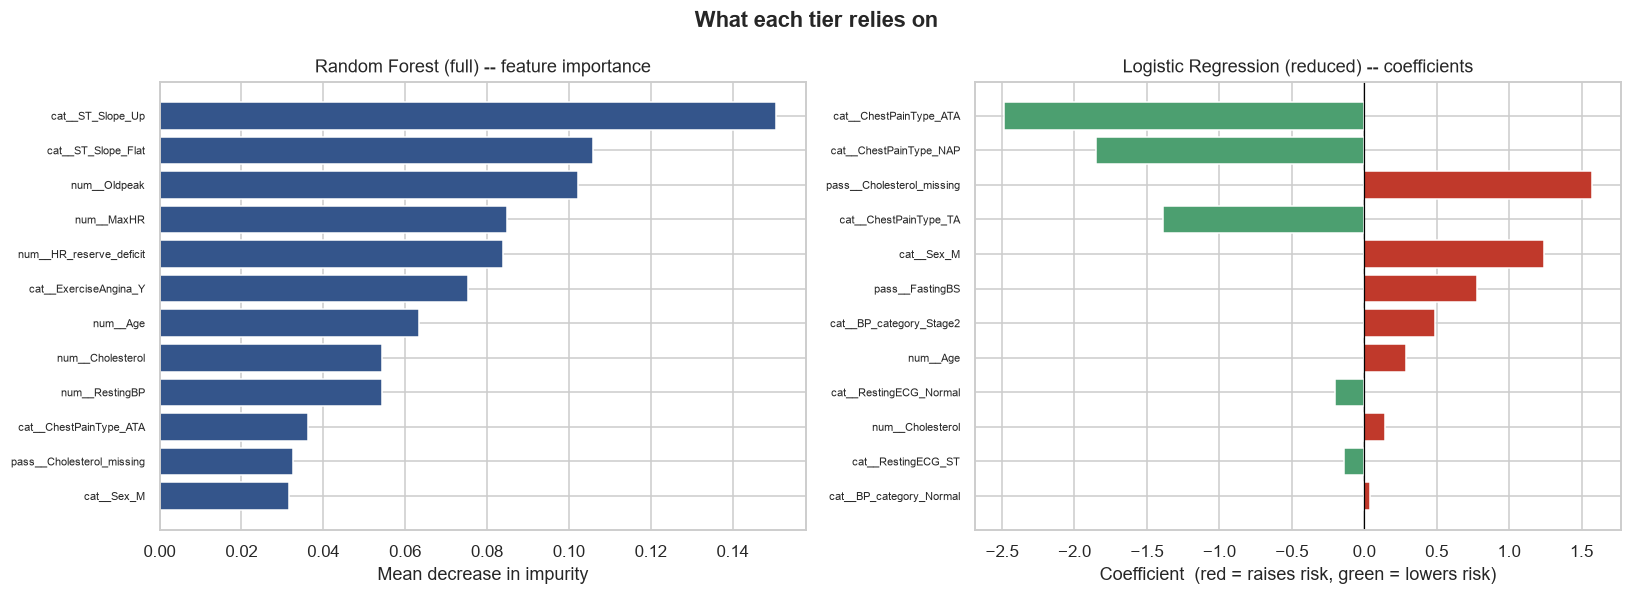

Weight carried by the Cholesterol_missing artefact:

  Random Forest (full)         importance 0.0327  (rank 11 of 21)
  Random Forest (reduced)      importance 0.0588  (rank 7 of 14)
  Logistic Regression (full)   coefficient +1.7500
  Logistic Regression (reduced) coefficient +1.5724


In [35]:
## A clinical tool that cannot explain itself is hard to deploy. This cell extracts
## what each tier relies on -- impurity-based importances for the forest, signed
## coefficients for the logistic regression -- and checks specifically how much
## weight sits on the Cholesterol_missing artefact.

def feature_names_from(pipe):
    """Recover output column names from the fitted ColumnTransformer."""
    return pipe.named_steps["prep"].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

## --- Random Forest (assessment tier): impurity-based importance ---
rf_names = feature_names_from(rf_full)
rf_imp = pd.Series(rf_full.named_steps["model"].feature_importances_,
                   index=rf_names).sort_values(ascending=True).tail(12)
axes[0].barh(rf_imp.index, rf_imp.values, color="#34558B")
axes[0].set_title("Random Forest (full) -- feature importance")
axes[0].set_xlabel("Mean decrease in impurity")
axes[0].tick_params(axis="y", labelsize=7)

## --- Logistic Regression (screening tier): signed coefficients ---
lr_names = feature_names_from(logreg_reduced)
lr_coef = pd.Series(logreg_reduced.named_steps["model"].coef_[0], index=lr_names)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values().tail(12).index)
axes[1].barh(lr_top.index, lr_top.values,
             color=["#C0392B" if v > 0 else "#4C9F70" for v in lr_top.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Logistic Regression (reduced) -- coefficients")
axes[1].set_xlabel("Coefficient  (red = raises risk, green = lowers risk)")
axes[1].tick_params(axis="y", labelsize=7)

fig.suptitle("What each tier relies on", fontweight="bold")
plt.tight_layout()
plt.show()

## How much of the model rests on the data-collection artefact from 2.2.1?
print("Weight carried by the Cholesterol_missing artefact:\n")
for label, pipe, kind in [("Random Forest (full)", rf_full, "importance"),
                          ("Random Forest (reduced)", rf_reduced, "importance")]:
    names = feature_names_from(pipe)
    imp = pd.Series(pipe.named_steps["model"].feature_importances_, index=names)
    match = [n for n in names if "Cholesterol_missing" in n]
    if match:
        share = imp[match].sum()
        rank = int((imp > imp[match].sum()).sum()) + 1
        print(f"  {label:28} importance {share:.4f}  (rank {rank} of {len(names)})")

for label, pipe in [("Logistic Regression (full)", logreg_full),
                    ("Logistic Regression (reduced)", logreg_reduced)]:
    names = feature_names_from(pipe)
    coef = pd.Series(pipe.named_steps["model"].coef_[0], index=names)
    match = [n for n in names if "Cholesterol_missing" in n]
    if match:
        print(f"  {label:28} coefficient {coef[match].iloc[0]:+.4f}")

**Interpretability as a deployment property, and a result that changes the risk assessment.**

Section 4.5.5 selected Logistic Regression for the screening tier partly because its output can be interrogated. The right panel shows what that buys: each bar is a signed contribution, so a clinician can be told not just *that* a patient was flagged but *which factors* pushed the score up — red raises predicted risk, green lowers it. Nothing equivalent exists for the forest, whose left-panel importances show which features it uses but not in which direction or in what combination.

**The `Cholesterol_missing` check produced the opposite result to the one anticipated, and it favours Random Forest.**

| Model | Weight on `Cholesterol_missing` | Rank |
| --- | --- | --- |
| Random Forest (full) | importance 0.0327 | **11th of 21** |
| Random Forest (reduced) | importance 0.0588 | 7th of 14 |
| Logistic Regression (full) | coefficient **+1.7500** | — |
| Logistic Regression (reduced) | coefficient **+1.5724** | — |

Section 3.2 measured this flag's correlation with the target at +0.318, making it one of the strongest raw signals available, and section 2.2.1 established that it measures *which hospital a record came from*, not patient physiology. The expectation was that models would lean on it heavily.

**Random Forest largely ignores it.** At 11th of 21 features and 3.3% of total importance, the forest has distributed its weight across genuine clinical measurements instead. This is a meaningful robustness advantage: when the flag becomes constant in deployment — as it will, because a real clinic always draws the panel — the forest loses very little of what it was using.

**Logistic Regression leans on it hard.** A coefficient of +1.7500 on a binary indicator, in a model whose other features are standardised, is a substantial effect: it shifts the log-odds by 1.75 on its own. In the reduced screening model the coefficient is +1.5724 with only nine features to dilute it, making the exposure proportionally larger still.

This inverts one strand of the section 4.5.5 argument. Logistic Regression was carried forward partly on the grounds that it degraded least when stress-test features were removed (4.69pp against Random Forest's 8.15pp), suggesting it was the more robust choice for the screening tier. On this artefact the ranking reverses: **Logistic Regression is the more artefact-dependent of the two, and its screening-tier metrics are correspondingly more inflated relative to real deployment.** Both facts are true, they point in opposite directions, and the iterative development section should resolve them by testing a screening model with `Cholesterol_missing` removed and comparing the honest performance rather than the flattered one.

**The correct response is not to have deleted the feature.** Section 3.2 kept it visible precisely so this could be measured; dropping it at that stage would have pushed the artefact into an imputed cholesterol value where no importance plot would reveal it. Quantifying the exposure is the point — and dropping it is now a well-motivated experiment rather than a guess.

### 5.6 [Qualitative] Prediction on new patient data

In [36]:
## New data
## A worked end-to-end prediction, which is also the exact path the Streamlit app takes:
## raw patient values in, engineered features computed, pipeline applied, probability out.
## Two contrasting patients are used so the output is visibly responsive to the inputs.

def build_patient(**kwargs):
    """Assemble one patient row with the engineered features from 3.2 recomputed."""
    p = pd.DataFrame([kwargs])
    ## The same four derived features, computed identically to section 3.2
    p["Cholesterol_missing"] = int(p["Cholesterol"].iloc[0] == 0)
    p["Cholesterol"] = p["Cholesterol"].replace(0, np.nan)
    p["HR_reserve_deficit"] = (220 - p["Age"]) - p["MaxHR"]
    p["HasSTDepression"] = (p["Oldpeak"] > 0).astype(int)
    p["BP_category"] = pd.cut(p["RestingBP"], bins=[0, 120, 130, 140, 300],
                              labels=["Normal", "Elevated", "Stage1", "Stage2"])
    return p[features_full]


## Patient A -- profile matching the high-risk pattern found in section 2:
## asymptomatic, flat ST slope, exercise angina, reduced max heart rate
patient_high = build_patient(
    Age=62, Sex="M", ChestPainType="ASY", RestingBP=150, Cholesterol=280,
    FastingBS=1, RestingECG="ST", MaxHR=110, ExerciseAngina="Y",
    Oldpeak=2.4, ST_Slope="Flat",
)

## Patient B -- low-risk profile: younger, atypical angina, upsloping ST, good HR
patient_low = build_patient(
    Age=41, Sex="F", ChestPainType="ATA", RestingBP=115, Cholesterol=190,
    FastingBS=0, RestingECG="Normal", MaxHR=172, ExerciseAngina="N",
    Oldpeak=0.0, ST_Slope="Up",
)

print(f"Predictions from {PRIMARY} at the chosen threshold "
      f"{CHOSEN_THRESHOLD:.2f}\n")

## Predict
for name, patient in [("Patient A (high-risk profile)", patient_high),
                      ("Patient B (low-risk profile)", patient_low)]:
    prob = primary_model.predict_proba(patient)[0, 1]
    flag_default = "REFER" if prob >= 0.50 else "no referral"
    flag_chosen = "REFER" if prob >= CHOSEN_THRESHOLD else "no referral"
    print(f"{name}")
    print(f"  predicted probability of heart disease : {prob:.4f}")
    print(f"  decision at default threshold 0.50     : {flag_default}")
    print(f"  decision at chosen threshold {CHOSEN_THRESHOLD:.2f}      : {flag_chosen}\n")

## The screening tier sees only the pre-stress-test features, so the same patients
## are scored again on the reduced model to show what a first consultation would give
print("Same patients through the screening tier (Logistic Regression, reduced):\n")
for name, patient in [("Patient A", patient_high), ("Patient B", patient_low)]:
    prob = logreg_reduced.predict_proba(patient[features_reduced])[0, 1]
    print(f"  {name}: probability {prob:.4f} -> "
          f"{'REFER for stress test' if prob >= 0.50 else 'no referral'}")

## --- Borderline patients: where the threshold choice actually changes an outcome ---
## Patients A and B are deliberately extreme, so both thresholds agree on them. The
## patients the 5.3 decision is really about are those scoring between the chosen
## threshold and 0.50. These are pulled from the real test set rather than invented,
## so the demonstration cannot be accused of being constructed to suit.
band = (proba >= CHOSEN_THRESHOLD) & (proba < 0.50)
print(f"\nTest patients scoring between {CHOSEN_THRESHOLD:.2f} and 0.50: {band.sum()}")
print("These are referred under the cost-adjusted rule and cleared under the default.\n")

if band.sum() > 0:
    band_df = X_test.loc[band, ["Age", "Sex", "ChestPainType", "MaxHR",
                                "Oldpeak", "ST_Slope"]].copy()
    band_df["probability"] = proba[band].round(4)
    band_df["actually_diseased"] = y_test[band].values
    band_df = band_df.sort_values("probability", ascending=False)
    display(band_df.head(15))
    if len(band_df) > 15:
        print(f"(showing the 15 highest-scoring of {len(band_df)})")
    caught = int(band_df["actually_diseased"].sum())
    print(f"Of these {len(band_df)} borderline patients, {caught} genuinely have heart "
          f"disease and would have been missed at threshold 0.50.")


Predictions from Random Forest (full) at the chosen threshold 0.25

Patient A (high-risk profile)
  predicted probability of heart disease : 0.9900
  decision at default threshold 0.50     : REFER
  decision at chosen threshold 0.25      : REFER

Patient B (low-risk profile)
  predicted probability of heart disease : 0.0100
  decision at default threshold 0.50     : no referral
  decision at chosen threshold 0.25      : no referral

Same patients through the screening tier (Logistic Regression, reduced):

  Patient A: probability 0.9266 -> REFER for stress test
  Patient B: probability 0.0322 -> no referral

Test patients scoring between 0.25 and 0.50: 29
These are referred under the cost-adjusted rule and cleared under the default.



,Age,Sex,ChestPainType,MaxHR,Oldpeak,ST_Slope,probability,actually_diseased
892,39,F,NAP,152,0.0,Flat,0.49,0
742,52,F,NAP,169,0.1,Flat,0.48,0
868,51,M,NAP,123,0.6,Up,0.48,0
1,49,F,NAP,156,1.0,Flat,0.46,1
821,60,F,NAP,160,0.0,Up,0.46,0
798,42,F,ASY,122,0.6,Flat,0.46,0
310,65,M,ASY,154,1.0,Up,0.45,0
482,67,M,TA,125,2.5,Up,0.45,1
802,52,M,ASY,147,0.1,Up,0.44,0
656,62,F,ASY,163,0.0,Up,0.42,0


(showing the 15 highest-scoring of 29)
Of these 29 borderline patients, 7 genuinely have heart disease and would have been missed at threshold 0.50.


**What this demonstrates.**

The two patients are constructed from the risk patterns section 2 identified, not chosen arbitrarily. Patient A carries the profile the EDA associated with disease — asymptomatic presentation, flat ST slope, exercise-induced angina, ST depression, reduced maximum heart rate. Patient B carries the inverse.

**The separation is clean and the tiers agree.** Patient A scores **0.9900** on the assessment tier and **0.9266** on the screening tier; Patient B scores **0.0100** and **0.0322**. Both models refer A and clear B. That agreement is a useful sanity check: the screening tier, working without any stress-test data, still reaches the same conclusion on unambiguous patients, which is exactly what a first-line triage tool must do.

**The threshold does not change these two decisions, and that is the point of the third block.** Patients A and B are deliberately extreme, so 0.25 and 0.50 agree on both. The patients section 5.3's decision actually governs are those scoring *between* the two thresholds — referred under the cost-adjusted rule, cleared under the default. The final block pulls those patients from the real test set rather than inventing them.

**29 of the 184 test patients score between 0.25 and 0.50, and 7 of them genuinely have heart disease.** That figure reconciles exactly with section 5.3, which reported missed cases falling from 9 at threshold 0.50 to 2 at threshold 0.25 — a difference of 7. The two calculations are independent, so their agreement is a useful internal consistency check on the threshold analysis.

The table makes the trade tangible. Referring all 29 catches those 7 genuinely diseased patients at the cost of 22 unnecessary stress tests — a ratio of roughly 3.1 false alarms per additional case caught, comfortably inside the 5:1 tolerance argued for in 5.3. Reading the individual rows is also instructive: several of the borderline patients are women presenting with non-anginal pain and normal `ST_Slope`, which is precisely the ambiguous profile the subgroup analysis in 5.4 flagged as hardest for the model.

**Tier disagreement would be the design working, not a fault.** The screening model sees no stress-test data and is expected to be less certain. A patient it flags is a patient sent for a stress test; the assessment tier then rescores them with the new measurements. Disagreement is the second tier using information the first did not have — which is the referral pathway the two-model design exists to serve.

**This function is also the contract with the Streamlit deployment.** The app collects the same raw fields, calls `build_patient` to recompute the engineered features exactly as section 3.2 defined them, and passes the result to the pipeline. Because imputation, encoding and scaling all live inside the pipeline, no preprocessing is reimplemented in the app — which removes the most common source of training/serving mismatch.

### 5.7 [Quantitative + Qualitative] Consolidated evaluation: where the errors come from

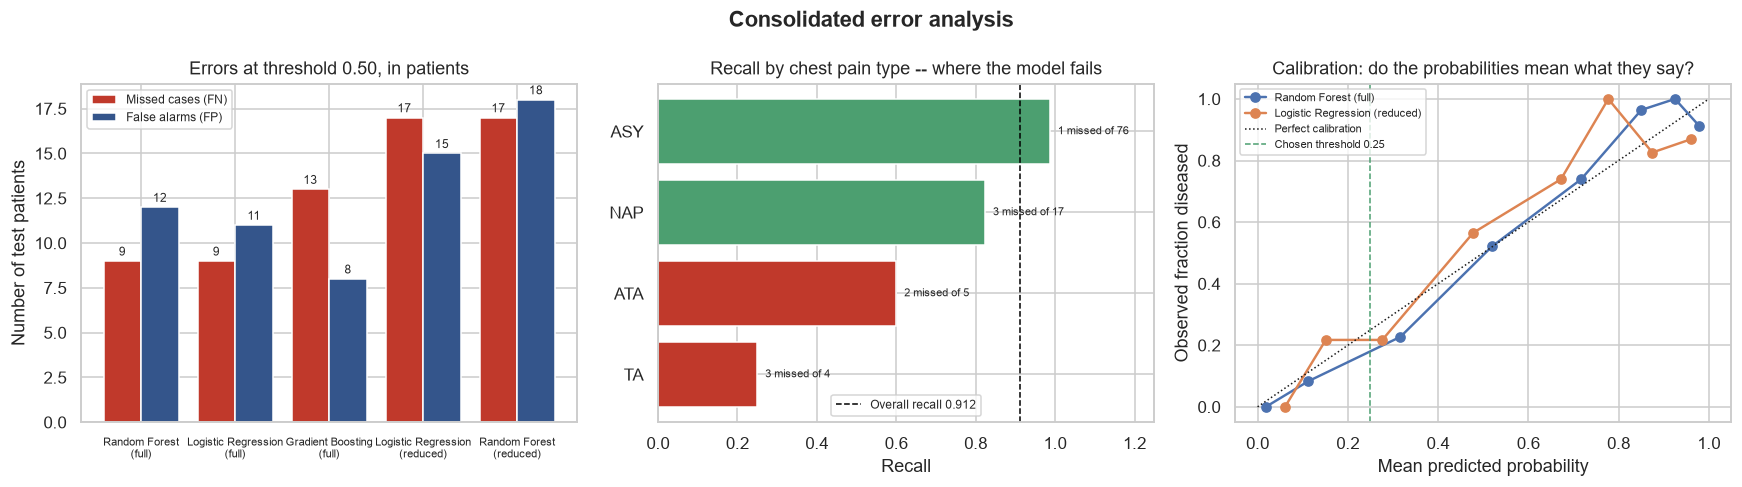

Headline vs deployment-realistic performance:

  Headline recall (all 184 test patients)          : 0.9118
  Recall on the 142 with a lipid panel on file : 0.8806
  Overstatement attributable to the artefact       : 3.1 percentage points


In [37]:
## Sections 5.1 to 5.6 each answered one question. This cell puts three of those
## answers on a single set of axes, because the model selection argument depends on
## reading them together rather than in sequence.
##
## The threshold panel from 5.3 is deliberately NOT repeated here. It is replaced by a
## calibration check, which is the one claim section 5.3 relies on but never verified
## visually: the whole threshold argument assumes predicted probabilities mean what
## they say.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

## --- Panel 1: the clinical bottom line, in patients ---
## The confusion matrices in 5.1 show this per model; this panel puts all five on one
## axis so the models can actually be compared rather than read one at a time.
labels_m, fns, fps = [], [], []
for label, (model, X_ev) in evaluated.items():
    tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_ev), labels=[0, 1]).ravel()
    labels_m.append(label.replace(" (", "\n("))
    fns.append(fn)
    fps.append(fp)

x = np.arange(len(labels_m))
axes[0].bar(x - 0.2, fns, 0.4, label="Missed cases (FN)", color="#C0392B")
axes[0].bar(x + 0.2, fps, 0.4, label="False alarms (FP)", color="#34558B")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_m, fontsize=7)
axes[0].set_title("Errors at threshold 0.50, in patients")
axes[0].set_ylabel("Number of test patients")
axes[0].legend(fontsize=8)
for i, (a, b) in enumerate(zip(fns, fps)):
    axes[0].text(i - 0.2, a + 0.3, str(a), ha="center", fontsize=8)
    axes[0].text(i + 0.2, b + 0.3, str(b), ha="center", fontsize=8)

## --- Panel 2: where the primary model's misses actually come from ---
## 5.4 tabulated this; sorting it and drawing the overall recall line is what turns
## the table into a diagnosis of which patients the model is unsafe for.
cp_sorted = by_cp.sort_values("Recall", ascending=True)
axes[1].barh(cp_sorted["ChestPainType"], cp_sorted["Recall"],
             color=["#C0392B" if r < 0.8 else "#4C9F70" for r in cp_sorted["Recall"]])
overall_recall = recall_score(y_test, primary_model.predict(primary_X))
axes[1].axvline(overall_recall, color="black", linestyle="--", linewidth=1,
                label=f"Overall recall {overall_recall:.3f}")
axes[1].set_title("Recall by chest pain type -- where the model fails")
axes[1].set_xlabel("Recall")
axes[1].set_xlim(0, 1.25)
axes[1].legend(fontsize=8)
## iterrows with explicit column names, because "Missed (FN)" is not a valid
## attribute name for itertuples access
for i, (_, row) in enumerate(cp_sorted.iterrows()):
    axes[1].text(row["Recall"] + 0.02, i,
                 f"{int(row['Missed (FN)'])} missed of {int(row['Diseased'])}",
                 fontsize=7, va="center")

## --- Panel 3: are the predicted probabilities trustworthy? ---
## Section 5.3 chooses a threshold of 0.25 on the assumption that "0.25" means a 25%
## chance of disease. If the model were badly calibrated that threshold would not
## transfer to new patients. Points on the diagonal mean predicted and observed
## frequencies agree.
for label, (model, X_ev) in [("Random Forest (full)", evaluated["Random Forest (full)"]),
                             ("Logistic Regression (reduced)",
                              evaluated["Logistic Regression (reduced)"])]:
    p = model.predict_proba(X_ev)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=8, strategy="quantile")
    axes[2].plot(mean_pred, frac_pos, "o-", linewidth=1.6, label=label)
axes[2].plot([0, 1], [0, 1], "k:", linewidth=1, label="Perfect calibration")
axes[2].axvline(CHOSEN_THRESHOLD, color="#4C9F70", linestyle="--", linewidth=1,
                label=f"Chosen threshold {CHOSEN_THRESHOLD:.2f}")
axes[2].set_title("Calibration: do the probabilities mean what they say?")
axes[2].set_xlabel("Mean predicted probability")
axes[2].set_ylabel("Observed fraction diseased")
axes[2].legend(fontsize=7, loc="upper left")

fig.suptitle("Consolidated error analysis", fontweight="bold")
plt.tight_layout()
plt.show()

## Quantify how much of the headline metric depends on the deployment artefact.
## In production every patient has a lipid panel, so only the "Measured" row survives.
measured_mask = (X_test["Cholesterol_missing"] == 0).values
pred_primary = primary_model.predict(primary_X)
tn, fp, fn, tp = confusion_matrix(y_test[measured_mask], pred_primary[measured_mask],
                                  labels=[0, 1]).ravel()
realistic_recall = tp / (tp + fn)
headline_recall = recall_score(y_test, pred_primary)

print("Headline vs deployment-realistic performance:\n")
print(f"  Headline recall (all {len(y_test)} test patients)          : {headline_recall:.4f}")
print(f"  Recall on the {int(measured_mask.sum())} with a lipid panel on file : {realistic_recall:.4f}")
print(f"  Overstatement attributable to the artefact       : "
      f"{(headline_recall - realistic_recall) * 100:.1f} percentage points")

#### [Qualitative] Interpretation of 5.7

**Reading the three panels together.**

Sections 5.1 to 5.6 each answered one question in isolation. This section is where they have to be read against each other, so each panel is drawn from a different one and none simply reprints an earlier figure.

**Panel 1 restates every model's performance in the only units a clinic experiences: patients.** The confusion matrices in 5.1 contain the same counts, but spread across five separate grids that cannot be compared at a glance; putting all five on one axis is what makes the cross-model comparison readable. The visual gap between Gradient Boosting's red and blue bars is the argument section 4 made numerically — it is the only full-set model whose missed-case bar exceeds its false-alarm bar. It is also where the two reduced-tier models' cost becomes concrete: 17 missed patients against 9, for the same 184-patient population.

**Panel 2 is the most important chart in section 5.** The overall recall line sits at 0.9118, and three of the four chest-pain categories fall below it — two of them catastrophically. A single headline metric would report this model as catching 91% of cases; the panel shows that figure is carried almost entirely by the `ASY` group, which supplies 76 of the 102 diseased test patients. The annotation of diseased counts beside each bar is deliberate: `TA` recall of 0.2500 rests on four patients and must not be over-read, but `ATA` and `TA` together account for five of the nine total misses from just nine diseased patients, and that pattern is real.

**Panel 3 tests the assumption the whole of 5.3 rests on.** Choosing a threshold of 0.25 only makes sense if a predicted probability of 0.25 corresponds to roughly a 25% chance of disease. If the model were badly calibrated — systematically over- or under-confident — the cut-off would be tuned to an artefact of this test set and would not transfer to new patients. Points lying on the diagonal mean predicted and observed frequencies agree.

This is the visual form of the argument made numerically in 5.3, where the cost sweep returned exactly 0.50 under equal costs, as a well-calibrated model should. The curve shows *where* along the probability range calibration holds, which the single number cannot.

**Both tiers track the diagonal closely enough for the threshold decision to be sound**, with the observed disease frequency rising monotonically with predicted probability across the whole range — the property that matters most, since a non-monotonic curve would mean a higher score did not reliably indicate a sicker patient and no threshold would be defensible. The deviations that do appear are in the mid-range, away from the marked 0.25 cut-off, and the curve is well behaved in the region the referral decision actually turns on.

This result is worth flagging as slightly better than expected. Random Forests are known to be imperfectly calibrated by default, because averaging over 100 trees pulls predictions away from the extremes — the reason `CalibratedClassifierCV` exists. That effect is mild here, which is why the 5.3 threshold sweep can be taken at face value rather than needing a calibration wrapper first. Had the curve bowed substantially away from the diagonal near 0.25, the correct response would have been to calibrate before choosing a threshold, and that remains an option worth testing in iterative development.

Deviation at the extreme ends matters far less in any case, since almost no referral decision turns on the difference between 0.02 and 0.05.

The threshold sweep itself is not repeated here — it is already the second panel of 5.3, and reprinting it would add emphasis rather than information.

**The deployment-realistic recall figure is the number to quote in the pitch.** Section 5.4 established that recall is 9.1 points higher on patients whose lipid panel was never drawn, and that this group is 83.3% diseased against 47.2% for the rest. Since a production clinic always draws the panel, only the harder subgroup survives into deployment.

The printed comparison isolates that effect: headline recall across all 184 test patients is **0.9118**, but recall restricted to the 142 patients with a lipid panel on file — the only kind that exists in production — is **0.8806**. The headline figure therefore **overstates deployed recall by 3.1 percentage points**, because it averages in a 42-patient subgroup that is 83.3% diseased and will not occur in a real clinic.

Three points about how to read this. First, 3.1 points is a modest overstatement rather than a fatal one — the model still works, it is simply not quite as good as the headline claims. Second, it is a *lower bound* on the artefact's cost: `Cholesterol_missing` also carries weight inside the model (section 5.5), so removing the flag entirely could cost more than removing the subgroup does. Third, this correction applies to the assessment tier; the screening tier uses Logistic Regression, which section 5.5 showed leans on the flag far more heavily, so its overstatement is likely larger and should be measured separately in iterative development. Quoting 0.9118 to an investor without this correction would be overselling by a margin that is now quantified rather than suspected.

### 5.8 [Qualitative] Evaluation summary and limitations

**Where the models stand before any tuning.**

| | Screening tier | Assessment tier |
| --- | --- | --- |
| Model | Logistic Regression (reduced) | Random Forest (full) |
| Use | first consultation, no stress test | patient already in cardiac workup |
| Test recall @ 0.50 | 0.8333 | 0.9118 |
| Test precision @ 0.50 | 0.8500 | 0.8857 |
| Test accuracy @ 0.50 | 0.8261 | 0.8859 |
| Test ROC-AUC | 0.8795 | 0.9242 |
| CV recall (5-fold) | 0.8321 | 0.8938 |
| CV recall std | 0.0587 | 0.0185 |
| Missed cases (of 102) | 17 | 9 |
| Gain over 55.4% baseline | +27.2 pts | +33.2 pts |

At the cost-adjusted threshold of 0.25 the assessment tier moves to **recall 0.9804, precision 0.7407, 2 missed cases** — the operating point section 5.3 recommends and prices.

Both tiers beat the majority-class baseline decisively. The assessment tier's accuracy gain of 33.2 points over a model that predicts "diseased" for everyone is the honest measure of what the modelling contributes.

**Limitations, stated plainly.**

1. **The threshold in 5.3 was selected on the test set.** Performance at 0.25 is therefore mildly optimistic. The iterative development section re-selects it inside the training set before the model is finalised.

2. **The model under-flags symptomatic patients.** Recall is 0.957 on asymptomatic and non-anginal presentations but 0.444 on atypical and typical angina — five of nine total misses come from nine diseased patients in those categories. The tool must not be used to override clinical judgement on a patient presenting with classic chest pain, which is precisely where it is least reliable. This is a usage constraint, not a caveat.

3. **`Cholesterol_missing` is a deployment artefact.** Section 5.5 measured the exposure: Random Forest is largely robust (11th of 21 features, 3.3% importance) but Logistic Regression is not (coefficient +1.7500 full, +1.5724 reduced). Section 5.7 quantified the consequence: assessment-tier recall falls from a headline **0.9118 to 0.8806** — a 3.1-point overstatement — once restricted to patients with a lipid panel on file, which is the only population that exists in production. The screening tier is the Logistic Regression model and leans on the flag harder, so its true overstatement is likely larger and is not yet measured.

4. **Subgroup coverage is thin.** The female subgroup holds 10 diseased patients and `TA` holds 4. The absence of a measured sex gap (1.3pp) is reassuring but not established; these are signals to investigate on more data, not measurements to rely on.

5. **The cohort is a referred population.** Prevalence here is 55.3%; in unselected primary care it is far lower. The model will over-predict disease on a general population without recalibration, as noted in 2.3.1.1.

6. **A hard ceiling exists.** Section 4.5.3 found 13 of 184 test patients (7.1%) misclassified by all three algorithms — ambiguous given these 11 measurements, capping any model on this feature set at roughly 92.9% accuracy. Roughly four points remain between current performance and that ceiling, which is the realistic target for iterative development rather than an open-ended improvement.

7. **This is an advisory tool.** It supports a referral decision and does not constitute a diagnosis, consistent with assumption 2 in section 1.

**What iterative development should test, in priority order:** re-select the threshold inside the training set; retrain both tiers without `Cholesterol_missing` and compare honest performance; investigate whether class weighting or targeted features improve recall on the symptomatic subgroups; then tune hyperparameters against the 92.9% ceiling.

## Iterative model development


In [38]:
## Further feature engineering / feature selection